# SFC CORE Model

In [1]:
%reload_ext autoreload
%autoreload 2
from model.parameters_baseline import ModelParameters
from model.calibration import ParametersCalibrated
parameters_calibrated = pc = ParametersCalibrated
import pandas as pd
import numpy as np
from io import StringIO
from model.utils import to_float_or_nan
# Import the LaTeX export module
from model.latex_export import (
    export_sectors_to_latex, 
    export_sectors_with_details_to_latex,
    export_vision2030_sectors_to_latex,
)
from model.export_calibrated_parameters_to_latex import export_calibrated_parameters_to_latex

# Load and calibrate parameters
parameters = ModelParameters.default_values()
parameters_calibrated = pc = ParametersCalibrated(parameters)

# Only two digits behind the comma
np.set_printoptions(suppress=True, precision=2)

c:\Users\mmies\KEN_model_public\model\calibration.py:210: RuntimeWarning: divide by zero encountered in divide
  np.isinf(self.X_ / self.Y_), 0, self.X_ / self.Y_)


## Inspect parameter data

In [4]:
print("Nominal GDP growth",pc.gY_avg)
# Real GDP growth (chain-linked, 2018=100), same window as pc.gY_avg (2013-2023)
real_gdp = pc.ts_national['Gross Domestic Product (4).1']
gY_real_avg = (real_gdp.loc[2023] / real_gdp.loc[2013]) ** (1 / 10) - 1

print(f"Nominal GDP growth 2013-2023 (pc.gY_avg): {pc.gY_avg:.2%}")
print(f"Real GDP growth 2013-2023:                {gY_real_avg:.2%}")
print(f"Real GDP growth 2003-2013:                {(real_gdp.loc[2013] / real_gdp.loc[2003]) ** (1 / 10) - 1:.2%}")
print(f"Real GDP growth 2018-2023:                {(real_gdp.loc[2023] / real_gdp.loc[2018]) ** (1 / 5) - 1:.2%}")
print(f"Gov. expenditure growth 2013-2023 (pc.gGY_avg): {pc.gGY_avg:.2%}")

Nominal GDP growth 0.03540637030598148
Nominal GDP growth 2013-2023 (pc.gY_avg): 3.54%
Real GDP growth 2013-2023:                2.32%
Real GDP growth 2003-2013:                4.88%
Real GDP growth 2018-2023:                1.79%
Gov. expenditure growth 2013-2023 (pc.gGY_avg): 2.66%


In [ ]:
# Export sectoral details to latex
# Attention: in Calibration, where this information is extracted, scenario_config: dict = None by default.
# This means you will get the latex table values for the parameters file. Change this in the calibration file if you want different values.
export_sectors_to_latex(pc)
export_sectors_with_details_to_latex(pc)
export_vision2030_sectors_to_latex(pc)
# Then call the function:
export_calibrated_parameters_to_latex(pc, parameters, include_csv_exports=True)

LaTeX table exported to: Tables\sectors_table.tex
Total sectors: 85
LaTeX table with details exported to: Tables\sectors_detailed_table.tex
Total sectors: 85
Vision 2030 sectors LaTeX table exported to: Tables\vision2030_sectors_table.tex
Total Vision 2030 sectors: 18

Calibrated parameters LaTeX table exported to: Tables\calibrated_parameters_complete.tex
Total parameters documented: 122

Exporting supplementary CSV and LaTeX files...
  - A_matrix_86x86.csv
  - A_matrix_86x86.tex (numbered indices, A4 landscape, tiny font)
  - Z_matrix_86x86.csv
  - Z_matrix_86x86.tex
  - sectoral_initial_values.csv
  - sectoral_initial_values.tex
  - sectoral_intensities.csv
  - sectoral_intensities.tex
  - aggregate_parameters.csv
  - aggregate_parameters.tex

Export complete!



'% Calibrated Model Parameters - Complete Reference\n% Generated automatically from calibration data\n% \n\n\\begin{longtable}{p{0.30\\textwidth} p{0.15\\textwidth} p{0.20\\textwidth} p{0.25\\textwidth}}\n\\caption{Calibrated Model Parameters (Saudi Arabia, Base Year 2021)} \\label{tab:calibrated_parameters_complete} \\\\\n\\toprule\n\\textbf{Parameter} & \\textbf{Symbol} & \\textbf{Value} & \\textbf{Source/Notes} \\\\\n\\midrule\n\\endfirsthead\n\n\\multicolumn{4}{c}%\n{{\\tablename\\ \\thetable{} -- continued from previous page}} \\\\\n\\toprule\n\\textbf{Parameter} & \\textbf{Symbol} & \\textbf{Value} & \\textbf{Source/Notes} \\\\\n\\midrule\n\\endhead\n\n\\midrule\n\\multicolumn{4}{r}{{Continued on next page}} \\\\\n\\endfoot\n\n\\bottomrule\n\\endlastfoot\n\n\\multicolumn{4}{l}{\\textbf{1. Production Technology Parameters}} \\\\\n\\midrule\nCapital productivity (baseline) & $e_K$ & 1 & Uniform across sectors \\\\\nCapital-output ratio & $KX$ & 3 & From structural CGE literature \\

In [ ]:
print("PIF value", pc.PIF)
print("GV government net financial investment position value", pc.GV)
print("PIF TO GV ratio in percent", pc.PIF / pc.GV * 100)

PIF value 3468750000.0
GV government net financial investment position value 2660401036.5166597
PIF TO GV ratio in percent 130.38447784330046


In [ ]:
# Remittances data
print("REMITTANCES DATA (1000 SAR)")
print(pc.ts_remittances.round(0).astype(int).to_string())
print("")
print(f"Base year (2021) remittances: {pc.remittances_base_year:,.0f} (1000 SAR) = {pc.remittances_base_year/1e6:.2f} Bn SAR")
print(f"Base year (2021) GDP: {pc.GDP:,.0f} (1000 SAR) = {pc.GDP/1e6:.2f} Bn SAR")
print(f"Remittances / GDP (2021): {pc.remittances_base_year / pc.GDP:.2%}")

REMITTANCES DATA (1000 SAR)
Year
1971       777275
1972      1004282
1973      1466982
1974      1943662
1975      2078825
1976      3707507
1977      5648832
1978     10666816
1979     14114789
1980     15352861
1981     20055383
1982     20050779
1983     19635956
1984     19815196
1985     19494714
1986     18000000
1987     18480000
1988     24380001
1989     31990001
1990     42080000
1991     51480000
1992     50172000
1993     58860000
1994     67792000
1995     62227000
1996     58097000
1997     56304000
1998     56003000
1999     52343000
2000     57713000
2001     56699000
2002     59451000
2003     55437300
2004     50831500
2005     53638000
2006     59785720
2007     61634420
2008     81360600
2009     99261500
2010    101508770
2011    106780970
2012    110597150
2013    131190700
2014    138465900
2015    145452630
2016    141912678
2017    135446106
2018    127055669
2019    116988932
2020    129734428
2021    152731833
2022    147560177
2023    144849608
2024    17461

In [ ]:
print("FDI data AGGREGATE")
print(pc.ts_fdi_aggregate.round(0).astype(int).to_string())
print("")
print("FDI STOCK data AGGREGATE")
print(pc.ts_fdi_stock_aggregate.round(0).astype(int).to_string())
print("")
print("FDI GROSS INFLOW data AGGREGATE")
print(pc.ts_fdi_gross_aggregate.round(0).astype(int).to_string())
print("")
print("FDI data KEN SECTORAL DETAIL")
print(pc.ts_fdi.round(0).astype(int).to_string())
print("")
print("FDI STOCK data KEN SECTORAL DETAIL")
print(pc.ts_fdi_stock.round(0).astype(int).to_string())
print("")
print("FDI GROSS INFLOW data KEN SECTORAL DETAIL")
print(pc.ts_fdi_gross.round(0).astype(int).to_string())

FDI data AGGREGATE
      Manufacturing  Financial and Insurance Activities  Construction  Wholesale And Retail Trade  Professional, Scientific and Technical Activities  Information and Communication  Mining and Quarrying  Real Estate Activities  Administrative and Support Service Activities  Arts, entertainment and recreation  Accommodation And Food Service Activities  Water supply; sewerage, waste management and remediation activities  Human Health and Social Work Activities  Electricity, Gas, Steam And Air Conditioning Supply  Education  Other service activities  Agriculture, forestry and fishing  Transportation and Storage      Total
Year                                                                                                                                                                                                                                                                                                                                                               

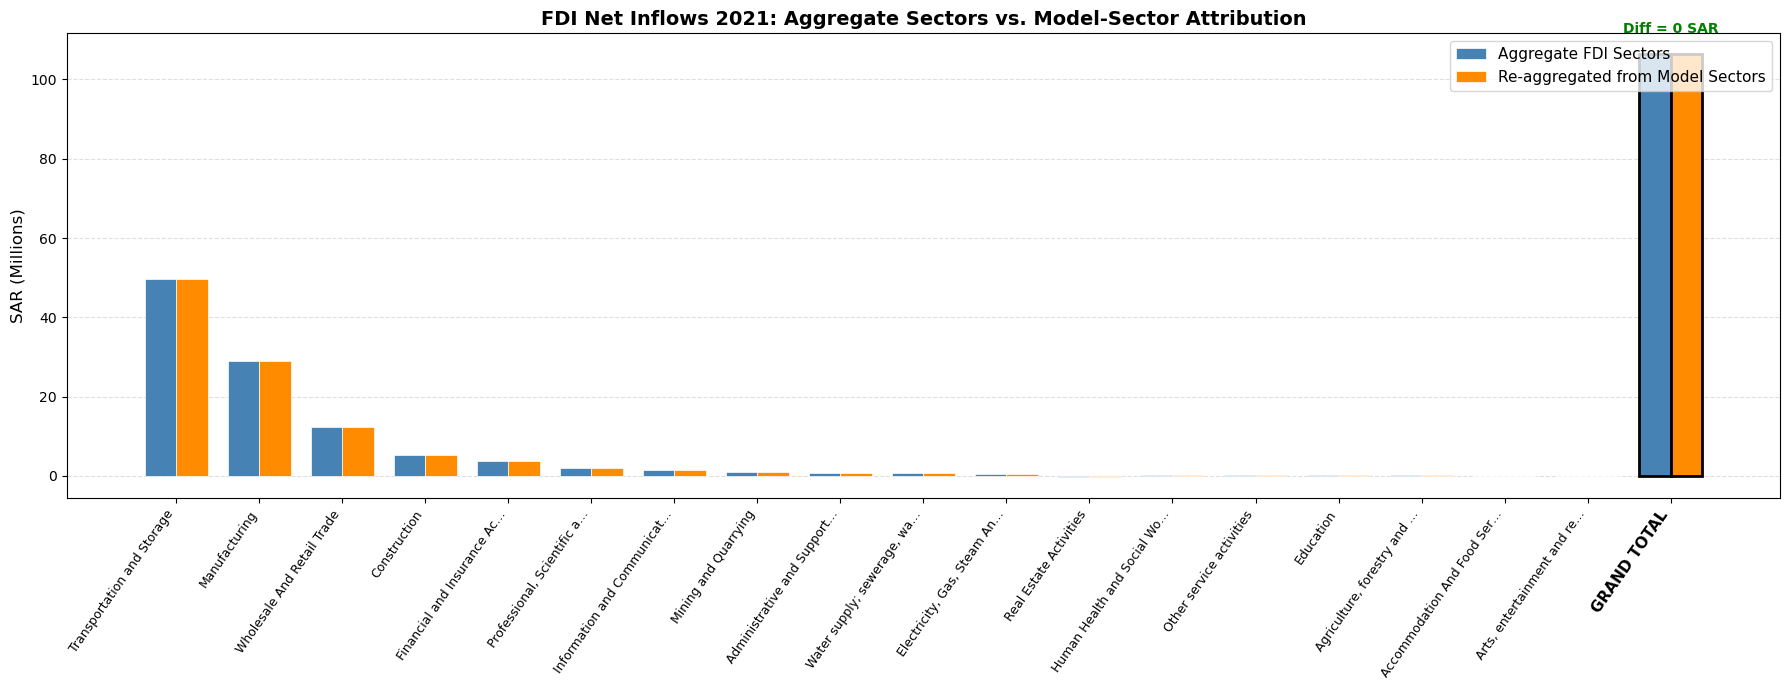


──────────────────────────────────────────────────────────────────────
  FDI Net Inflows 2021: Aggregate Sectors vs. Model-Sector Attribution
──────────────────────────────────────────────────────────────────────
  Sector                                              Aggregate   Disaggregated         Diff
  ───────────────────────────────────────────────────────────────────────────────────────
  Transportation and Storage                         49,567,696      49,567,696  ✓
  Manufacturing                                      28,945,760      28,945,760  ✓
  Wholesale And Retail Trade                         12,361,821      12,361,821  ✓
  Construction                                        5,322,989       5,322,989  ✓
  Financial and Insurance Activities                  3,649,829       3,649,829  ✓
  Professional, Scientific and Technical Activities       1,961,959       1,961,959  ✓
  Information and Communication                       1,527,562       1,527,562  ✓
  Mining and Quarr

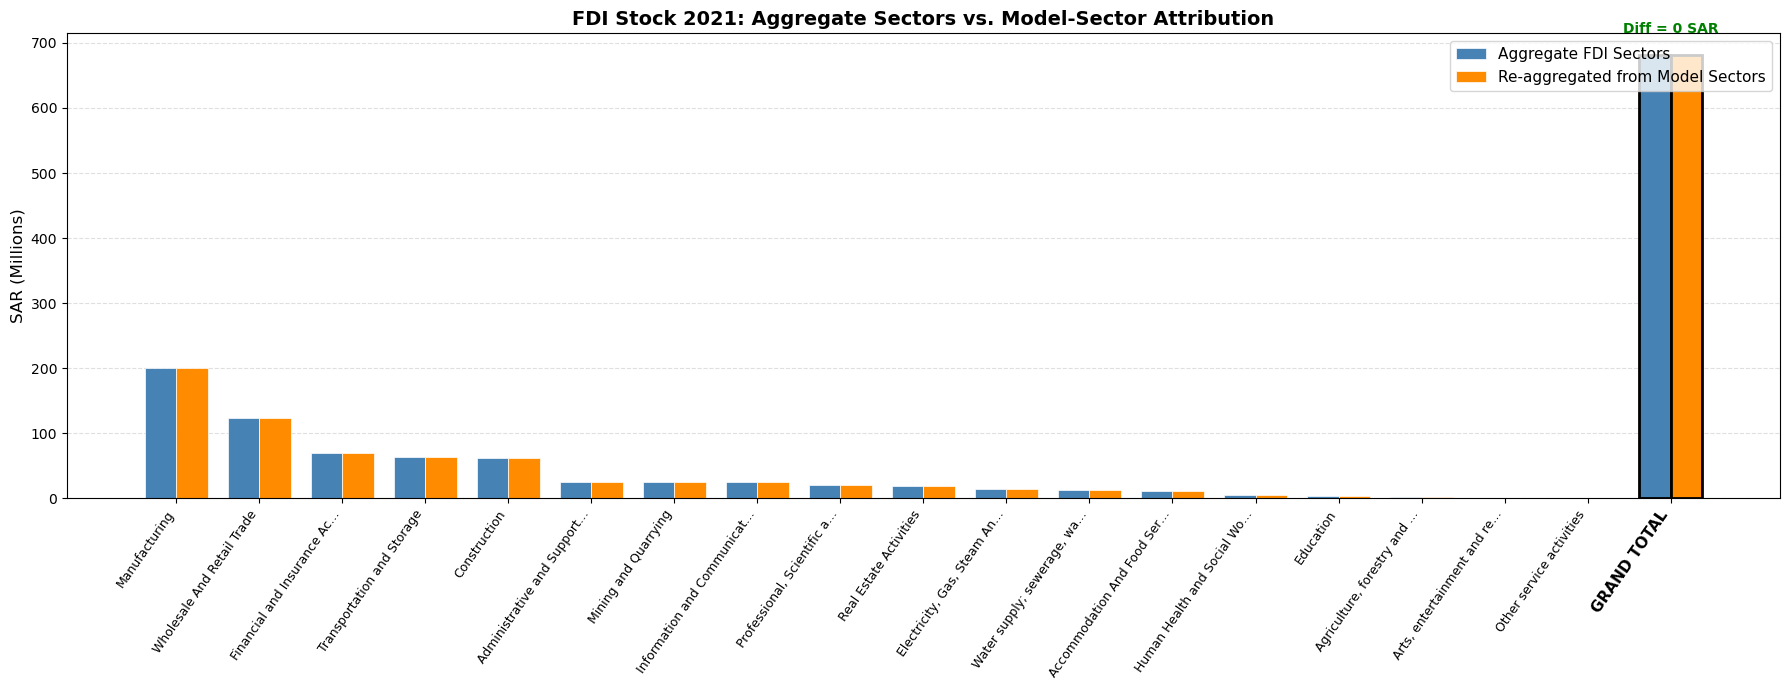


──────────────────────────────────────────────────────────────────────
  FDI Stock 2021: Aggregate Sectors vs. Model-Sector Attribution
──────────────────────────────────────────────────────────────────────
  Sector                                              Aggregate   Disaggregated         Diff
  ───────────────────────────────────────────────────────────────────────────────────────
  Manufacturing                                     200,183,347     200,183,347  ✓
  Wholesale And Retail Trade                        123,071,334     123,071,334  ✓
  Financial and Insurance Activities                 70,147,399      70,147,399  ✓
  Transportation and Storage                         63,513,539      63,513,539  ✓
  Construction                                       61,619,436      61,619,436  ✓
  Administrative and Support Service Activities      25,008,604      25,008,604  ✓
  Mining and Quarrying                               24,964,341      24,964,341  ✓
  Information and Communicat

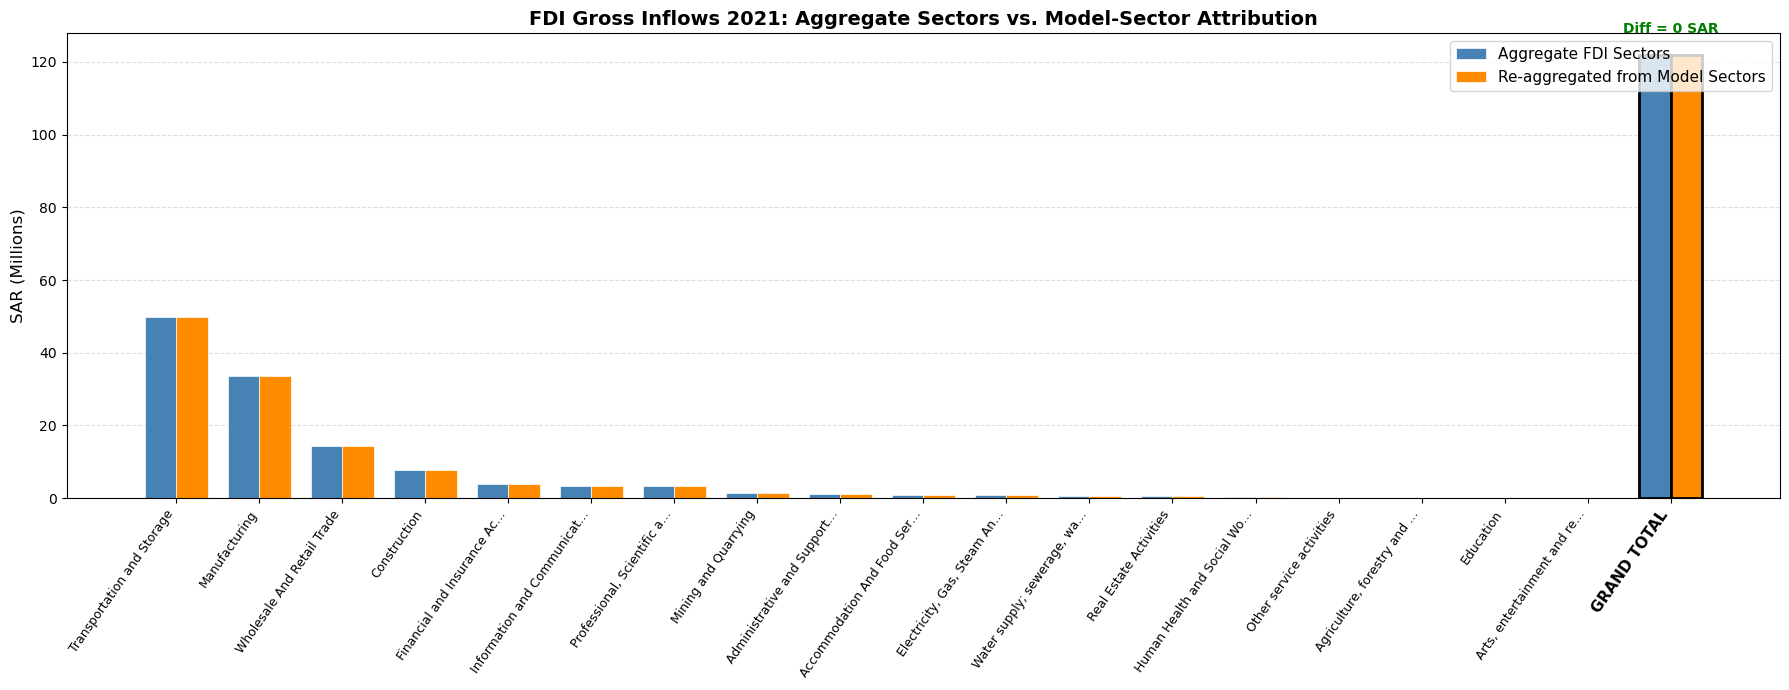


──────────────────────────────────────────────────────────────────────
  FDI Gross Inflows 2021: Aggregate Sectors vs. Model-Sector Attribution
──────────────────────────────────────────────────────────────────────
  Sector                                              Aggregate   Disaggregated         Diff
  ───────────────────────────────────────────────────────────────────────────────────────
  Transportation and Storage                         49,757,262      49,757,262  ✓
  Manufacturing                                      33,528,371      33,528,371  ✓
  Wholesale And Retail Trade                         14,247,912      14,247,912  ✓
  Construction                                        7,793,650       7,793,650  ✓
  Financial and Insurance Activities                  3,821,513       3,821,513  ✓
  Information and Communication                       3,300,931       3,300,931  ✓
  Professional, Scientific and Technical Activities       3,275,368       3,275,368  ✓
  Mining and Qua

In [ ]:
# VERIFY FDI INPUT VISUALLY
from model.visuals_FDI_input import plot_fdi_attribution; plot_fdi_attribution(pc, year=2021)

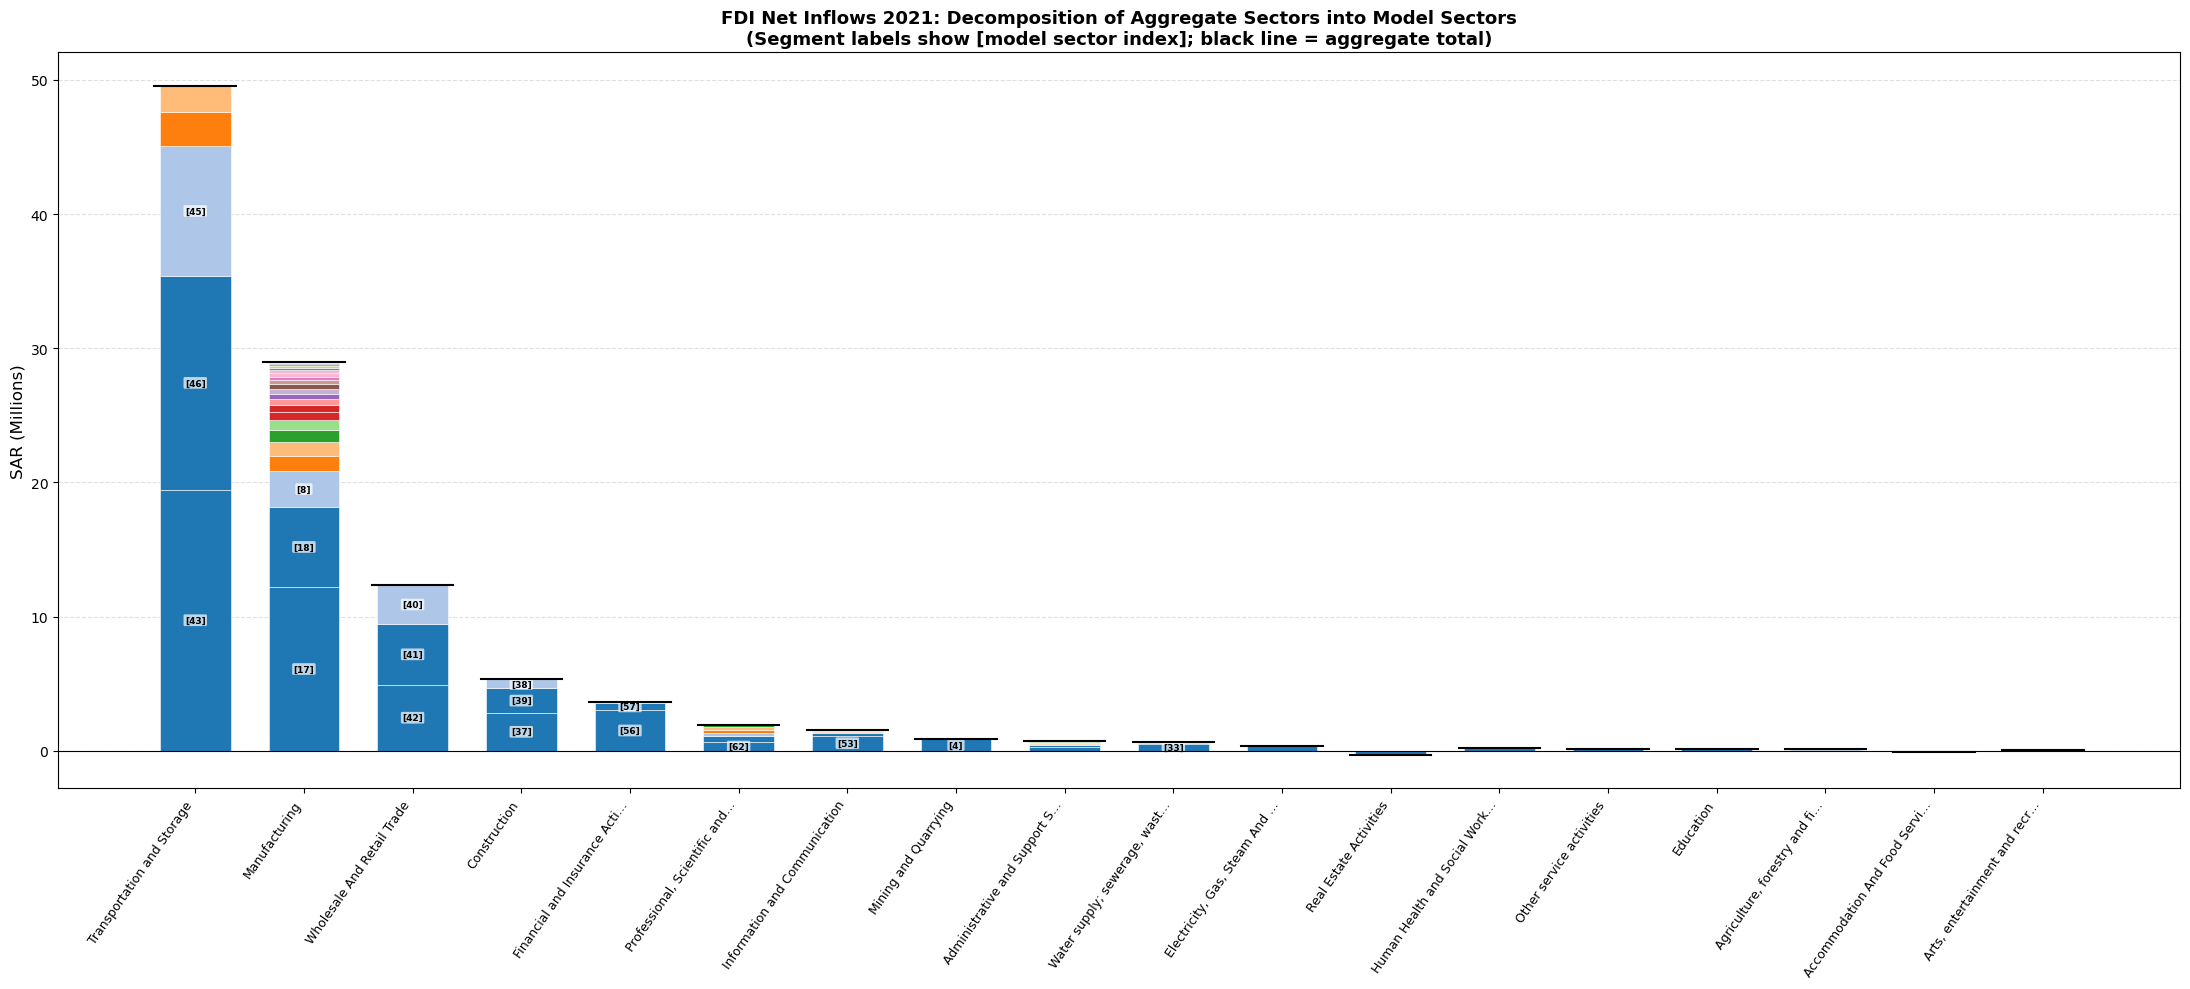


════════════════════════════════════════════════════════════════════════════════════════════════════
  FDI Net Inflows 2021: Model-Sector Decomposition Legend
════════════════════════════════════════════════════════════════════════════════════════════════════

  ▸ Transportation and Storage  (Aggregate: 49,567,696 SAR)
    Idx    Model Sector                                                          Value (SAR)    Share
    ───────────────────────────────────────────────────────────────────────────────────────────────
    [43 ]  Land transport and transport via pipelines                             19,472,487    39.3%
    [46 ]  Warehousing and support activities for transportation                  15,889,542    32.1%
    [45 ]  Air transport                                                           9,726,363    19.6%
    [44 ]  Water transport                                                         2,535,816     5.1%
    [47 ]  Postal and courier activities                            

In [ ]:
from model.visuals_FDI_input import plot_fdi_decomposition
plot_fdi_decomposition(pc, year=2021)

In [ ]:
pc.sectors

['Crop and animal production, hunting and related service activities',
 'Forestry and logging',
 'Fishing and aquaculture',
 'Mining of coal and lignite',
 'Extraction of crude petroleum and natural gas',
 'Mining of metal ores',
 'Other mining and quarrying activities',
 'Mining support service activities',
 'Manufacture of food products',
 'Manufacture of beverages',
 'Manufacture of tobacco products',
 'Manufacture of textiles',
 'Manufacture of wearing apparel',
 'Manufacture of leather and related products',
 'Manufacture of woods, wood products and cork except furniture',
 'Manufacture of paper and paper products',
 'Printing and reproduction of recorded media',
 'Manufacture of coke and refined petroleum products',
 'Manufacture of chemicals and chemical products',
 'Manufacture of basic pharmaceutical products and pharmaceutical preparations',
 'Manufacture of rubber and plastics products',
 'Manufacture of other non-metallic mineral products',
 'Manufacture of basic metals',
 

In [ ]:
pc.sectors_AI_hightech

[24, 25, 26, 52, 53, 54, 55, 62, 63]

In [ ]:
pc.sector_wwater

34

In [ ]:
pc.sectoral_yearly_growth_rates_V2030_

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.03, 0.  ,
       0.  , 0.  , 0.03, 0.03, 0.03, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.03, 0.03, 0.03, 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.03, 0.03, 0.  , 0.  , 0.03, 0.03, 0.03,
       0.03, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.03, 0.03, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.03, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.03, 0.03, 0.  , 0.  , 0.  , 0.  ])

In [ ]:
pc.FDI_yearly_target_growth_rate

0.03809344426552097

In [ ]:
pc.sectors.index('Sewerage')

34

In [ ]:
print("rm",pc.rm)

rm 0.0014681853300077513


In [ ]:
print("pc.α2 ORIGINAL", pc.α2)

pc.α2 ORIGINAL 0.43354393947190983


In [ ]:
print("TS NATIONAl DATA")
# print(pc.ts_national)
print("pc.inflation_avg",pc.inflation_avg)
print("GDP growth 2021 gY_2021",pc.gY_2021)
print("GDP growth 2022 gY_2022",pc.gY_2022)
print("GDP growth 2023 gY_2023",pc.gY_2023)
print("Inflation 2021",pc.inflation_2021)
print("Inflation 2022",pc.inflation_2022)
print("Inflation 2023",pc.inflation_2023)
print("CHECK pc.inflation_avg_CHECK",pc.inflation_avg_CHECK)
print("self.Deflator_optimal_lag_aic",pc.Deflator_optimal_lag_aic)
print("Overall price index GDP economy",pc.GDP_deflator)
print("Oil sector price index",pc.Oil_sector_deflator)
print("Non-oil sector price index",pc.Non_oil_sector_deflator)


#print(pc.ts_national['GDP (5)'])
#print(pc.ts_national['Oil Sector (5)'])
# print(pc.ts_national['Non-oil Sector (5)'])
#print("Y_optimal_lag_aic",pc.Y_optimal_lag_aic)
#print("GY_optimal_lag_aic",pc.GY_optimal_lag_aic)

TS NATIONAl DATA
pc.inflation_avg 0.023393003983865235
GDP growth 2021 gY_2021 0.19050854100449066
GDP growth 2022 gY_2022 0.26816194169624863
GDP growth 2023 gY_2023 -0.03697418738081981
Inflation 2021 0.00252306882034814
Inflation 2022 0.03639044832969529
Inflation 2023 0.033726377317242484
CHECK pc.inflation_avg_CHECK 0.023393003983865235
self.Deflator_optimal_lag_aic 1
Overall price index GDP economy 1970    0.041061
1971    0.047473
1972    0.049658
1973    0.056073
1974    0.140535
1975    0.151753
1976    0.180860
1977    0.197695
1978    0.205921
1979    0.255668
1980    0.351863
1981    0.389102
1982    0.390877
1983    0.373076
1984    0.367116
1985    0.353189
1986    0.299212
1987    0.307845
1988    0.297412
1989    0.319970
1990    0.360755
1991    0.374706
1992    0.371476
1993    0.358948
1994    0.361461
1995    0.382112
1996    0.409419
1997    0.417215
1998    0.359394
1999    0.398504
2000    0.445962
2001    0.431820
2002    0.447726
2003    0.468515
2004    0.5170

In [ ]:
print("pc.Y_non_oil_",pc.Y_non_oil_)
print("pc.Y_oil_",pc.Y_oil_)

pc.Y_non_oil_ [ 2.60e+07 -6.04e+04  9.60e+06 -1.97e+05  0.00e+00 -1.74e+06  1.14e+06
 -6.32e+05  6.90e+07  7.65e+06 -1.44e+06  5.95e+06  8.84e+06 -9.19e+04
 -4.25e+06  1.19e+06  5.50e+05  0.00e+00  1.39e+08 -1.80e+06 -4.92e+06
  4.79e+06 -1.80e+07  2.53e+07 -1.89e+06  1.51e+07 -2.94e+06  4.17e+05
  8.07e+04  1.42e+07 -8.23e+04  5.86e+06  2.76e+07  1.63e+07  1.76e+06
  1.50e+06  4.83e+04  1.85e+08  4.37e+07  1.17e+08  9.51e+07  1.31e+08
  1.37e+08  1.63e+07  1.76e+06  8.62e+06  5.26e+06  2.47e+06  4.07e+07
  4.50e+07  2.61e+06  1.27e+05  1.65e+06  6.36e+07  7.27e+06  7.10e+05
  5.22e+07  9.41e+06  9.96e+05  1.91e+08 -1.92e+06  1.06e+06  2.93e+06
  2.73e+06  4.54e+06  1.05e+06  1.43e+05  3.91e+06 -2.66e+06 -2.34e+06
 -2.27e+06 -4.19e+06 -1.56e+06  4.06e+08  1.98e+08  1.56e+08  8.42e+05
  4.94e+06  2.14e+06  4.15e+06  8.41e+06  1.31e+07  3.45e+06  3.74e+07
  0.00e+00]
pc.Y_oil_ [ 0.00e+00 -0.00e+00  0.00e+00 -0.00e+00  6.27e+08 -0.00e+00  0.00e+00
 -0.00e+00  0.00e+00  0.00e+00 -0.00e+00 

In [ ]:
#pc.non_oil_export_growth_adjustment_sectoral_

In [ ]:
print("pc.vision2030_sectors",pc.vision2030_sectors)
print("pc.sectors_tourism",pc.sectors_tourism)
print("pc.sectors_AI_hightech",pc.sectors_AI_hightech)

pc.vision2030_sectors [20, 24, 25, 26, 37, 38, 39, 48, 49, 52, 53, 54, 55, 62, 63, 69, 79, 80]
pc.sectors_tourism [48, 49, 69, 79, 80]
pc.sectors_AI_hightech [24, 25, 26, 52, 53, 54, 55, 62, 63]


In [ ]:
print(" pc.electricity_gas_AC_sector", pc.electricity_gas_AC_sector)
print("pc.s_private_",pc.s_private_)
print("pc.s_public_",pc.s_public_)


 pc.electricity_gas_AC_sector [32]
pc.s_private_ [1.   1.   1.   1.   0.35 1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   0.35 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   0.2  1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 0.  ]
pc.s_public_ [0.   0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.8  0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 1.  ]


In [ ]:
print("pc.sectoral_yearly_growth_rates_V2030_",pc.sectoral_yearly_growth_rates_V2030_*100,"percent")

pc.sectoral_yearly_growth_rates_V2030_ [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   2.96 0.   0.   0.   2.96 2.96 2.96 0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   2.96 2.96 2.96 0.   0.
 0.   0.   0.   0.   0.   0.   2.96 2.96 0.   0.   2.96 2.96 2.96 2.96
 0.   0.   0.   0.   0.   0.   2.96 2.96 0.   0.   0.   0.   0.   2.96
 0.   0.   0.   0.   0.   0.   0.   0.   0.   2.96 2.96 0.   0.   0.
 0.  ] percent


In [ ]:
pc.gross_capital_formation

array([ 1.28e+07,  3.90e+03, -4.06e+05, -5.94e+04,  2.25e+07, -3.74e+06,
        1.32e+06,  5.00e+04, -2.88e+06, -4.13e+05,  5.09e+04, -2.07e+05,
        1.42e+06,  3.36e+05, -1.04e+05,  9.54e+04,  4.13e+04, -1.09e+07,
        1.00e+07,  1.09e+05, -1.66e+05,  2.95e+06,  1.53e+07,  3.37e+07,
        2.24e+07,  5.35e+07,  4.10e+07,  3.39e+07,  1.35e+07,  1.15e+07,
        9.41e+06,  6.32e+02, -1.46e+04, -3.21e+04,  2.08e+01,  1.27e+04,
        0.00e+00,  1.95e+08,  4.58e+07,  1.22e+08,  1.05e+07,  5.01e+07,
        5.11e+07,  4.55e+06,  8.21e+05,  1.24e+06,  4.06e+03,  1.68e+03,
        4.26e+01,  1.56e+02,  4.45e+05,  1.63e+04,  3.34e+05,  1.89e+07,
        4.97e+06,  1.74e+06,  0.00e+00,  0.00e+00,  0.00e+00,  7.08e+03,
        1.58e+06,  1.26e+06,  3.47e+06,  5.09e+06,  8.14e+06,  1.24e+06,
        1.61e+05,  3.39e+06,  1.56e+00,  9.89e+01,  0.00e+00,  1.65e+05,
        1.70e+03,  7.79e+04,  2.01e+02,  9.43e+02,  0.00e+00,  0.00e+00,
        2.06e+05,  3.49e+05,  8.37e+05,  0.00e+00, 

In [ ]:
print(np.sum(pc.K_))

15984823110.655247


In [ ]:
pc.X_


array([1.37e+08, 2.07e+05, 1.23e+07, 2.53e+03, 8.97e+08, 5.20e+06,
       1.20e+07, 5.32e+06, 1.02e+08, 1.42e+07, 1.08e+05, 1.28e+07,
       1.23e+07, 7.16e+05, 8.85e+06, 2.08e+07, 9.12e+06, 4.71e+08,
       2.31e+08, 5.92e+06, 2.24e+07, 4.55e+07, 3.88e+07, 3.60e+07,
       1.09e+06, 2.87e+07, 1.45e+07, 6.20e+06, 2.76e+06, 1.70e+07,
       5.90e+06, 9.85e+06, 8.76e+07, 2.03e+07, 2.43e+06, 2.50e+06,
       6.66e+04, 2.41e+08, 5.69e+07, 1.53e+08, 1.70e+08, 2.62e+08,
       2.88e+08, 5.90e+07, 7.68e+06, 2.95e+07, 4.81e+07, 5.89e+06,
       5.76e+07, 6.38e+07, 7.18e+06, 2.73e+05, 2.49e+06, 1.38e+08,
       2.31e+07, 1.26e+07, 1.08e+08, 1.95e+07, 2.07e+06, 2.41e+08,
       5.26e+06, 5.29e+06, 1.45e+07, 3.09e+06, 9.95e+06, 4.76e+06,
       6.84e+05, 1.26e+07, 8.23e+06, 7.22e+06, 7.01e+06, 2.22e+07,
       4.88e+06, 4.26e+08, 2.12e+08, 1.68e+08, 9.20e+05, 5.37e+06,
       2.93e+06, 5.48e+06, 1.16e+07, 1.39e+07, 5.80e+06, 4.96e+07,
       3.71e+06])

In [ ]:
pc.ts_national

,Gross Fixed Capital Formation By Type Of Capital Assets At Current Prices,Residential Building Construction (1),Non- Residential Building and Other Construction (1),Other Construction (1),Transport Equip (1),Machinery and Equipment (1),Capital Goods not Classified Elsewhere (1) (1),All Capital Goods,TOTAL (1),(a) Government (1),...,Government Sector (5).1,Private Sector (5).1,Total (5).1,Net Taxes on Products (5).1,Gross Domestic Product (5).1,Contribution Of Services Sector To GDP,Total GDP (2) (6),Services Activity (3) (6),Share % (6),Change % (6)
1970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.124842e+07,7.787202e+07,1.357195e+08,3.985777e+06,5.845624e+08,NaN,2.391171e+07,8.789170e+06,36756.761014,NaN
1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.807694e+07,8.399639e+07,1.468860e+08,5.031147e+06,6.735862e+08,NaN,3.186404e+07,9.743166e+06,30577.304623,10854.220946
1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.719636e+07,9.511052e+07,1.658204e+08,5.537086e+06,8.001195e+08,NaN,3.961563e+07,1.153820e+07,29125.370625,18423.505659
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.015684e+08,1.151327e+08,1.990319e+08,5.463601e+06,9.801080e+08,NaN,5.492137e+07,1.509005e+07,27475.733310,30783.405970
1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.183630e+08,1.667130e+08,2.759588e+08,4.875626e+06,1.137902e+09,NaN,1.607741e+08,2.550017e+07,15860.875874,68986.675477
1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.386029e+08,2.143321e+08,3.494185e+08,4.925254e+06,1.075452e+09,NaN,1.640158e+08,4.448460e+07,27122.147211,74448.229159
1976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.430069e+08,2.236084e+08,3.639302e+08,4.932320e+06,1.239174e+09,NaN,2.250319e+08,6.419870e+07,28528.717042,44316.687532
1977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.584409e+08,2.308878e+08,3.800510e+08,6.225236e+06,1.312179e+09,NaN,2.601104e+08,8.231141e+07,31644.798245,28213.516569
1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.618234e+08,2.576388e+08,4.170945e+08,5.728535e+06,1.314440e+09,NaN,2.710444e+08,1.035091e+08,38189.002190,25753.092852
1979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.593194e+08,2.828638e+08,4.483047e+08,5.246495e+06,1.458554e+09,NaN,3.737782e+08,1.266756e+08,33890.594500,22381.112091


In [ ]:
pc.wage_share_in_X_ * 100

array([  6.48,  12.92,   5.13,  21.51,   5.01,  11.36,   4.57,  14.35,
         8.31,  13.3 ,  10.11,   6.02,  14.37,  14.26,   9.57,   8.29,
         8.7 ,   2.61,   9.51,  16.05,   6.92,  15.2 ,  10.48,  12.14,
         9.63,   7.61,  15.37,  15.12,  11.41,  15.15,   9.25,  18.76,
        13.07,  18.86,  18.97,  12.29,  49.87,  13.64,  13.06,   6.76,
         8.27,   4.15,  12.24,  12.58,   6.79,  18.8 ,  21.11,  40.16,
         7.32,  17.92,  11.72,  25.4 ,  48.38,   8.79,  21.16,   9.55,
        22.15,  22.7 ,  51.39,   2.67,  18.17,  14.86,  23.3 ,  41.68,
        17.5 ,  14.62,  12.51,  12.08,  40.33,  19.98,  20.24,  23.3 ,
        26.02,  60.71,  74.73,  50.58,   5.93,  11.69,   6.11,  10.91,
        11.82,  60.62,  17.27,  67.92, 103.46])

In [ ]:
pc.Y_

array([ 2.60e+07, -6.04e+04,  9.60e+06, -1.97e+05,  6.27e+08, -1.74e+06,
        1.14e+06, -6.32e+05,  6.90e+07,  7.65e+06, -1.44e+06,  5.95e+06,
        8.84e+06, -9.19e+04, -4.25e+06,  1.19e+06,  5.50e+05,  1.76e+08,
        1.39e+08, -1.80e+06, -4.92e+06,  4.79e+06, -1.80e+07,  2.53e+07,
       -1.89e+06,  1.51e+07, -2.94e+06,  4.17e+05,  8.07e+04,  1.42e+07,
       -8.23e+04,  5.86e+06,  2.76e+07,  1.63e+07,  1.76e+06,  1.50e+06,
        4.83e+04,  1.85e+08,  4.37e+07,  1.17e+08,  9.51e+07,  1.31e+08,
        1.37e+08,  1.63e+07,  1.76e+06,  8.62e+06,  5.26e+06,  2.47e+06,
        4.07e+07,  4.50e+07,  2.61e+06,  1.27e+05,  1.65e+06,  6.36e+07,
        7.27e+06,  7.10e+05,  5.22e+07,  9.41e+06,  9.96e+05,  1.91e+08,
       -1.92e+06,  1.06e+06,  2.93e+06,  2.73e+06,  4.54e+06,  1.05e+06,
        1.43e+05,  3.91e+06, -2.66e+06, -2.34e+06, -2.27e+06, -4.19e+06,
       -1.56e+06,  4.06e+08,  1.98e+08,  1.56e+08,  8.42e+05,  4.94e+06,
        2.14e+06,  4.15e+06,  8.41e+06,  1.31e+07, 

In [ ]:
print("Intermediate purchses matrix",pc.IntP_)

Intermediate purchses matrix [5.73e+07 9.36e+04 6.42e+06 5.58e+02 1.07e+08 1.49e+06 4.35e+06 2.25e+06
 5.45e+07 7.77e+06 1.75e+04 6.37e+06 5.36e+06 3.66e+05 5.00e+06 9.06e+06
 4.75e+06 3.35e+08 1.18e+08 3.68e+06 1.06e+07 2.50e+07 2.43e+07 1.66e+07
 5.79e+05 1.69e+07 7.90e+06 2.94e+06 1.76e+06 9.16e+06 2.97e+06 5.37e+06
 4.78e+07 1.46e+07 1.24e+06 5.10e+05 1.97e+04 1.42e+08 3.83e+07 9.17e+07
 1.00e+08 1.63e+08 1.75e+08 2.51e+07 4.74e+06 1.77e+07 1.91e+07 2.24e+06
 3.09e+07 3.12e+07 2.20e+06 6.63e+04 5.31e+05 6.38e+07 1.02e+07 6.22e+06
 1.33e+07 4.40e+05 3.31e+05 2.88e+07 3.18e+06 3.08e+06 5.75e+06 1.13e+06
 4.72e+06 2.34e+06 2.62e+05 5.70e+06 2.38e+06 4.15e+06 4.09e+06 8.66e+06
 2.28e+06 1.20e+08 2.41e+07 5.29e+07 5.13e+05 1.70e+06 1.22e+06 4.12e+06
 5.75e+06 4.02e+06 2.51e+06 9.07e+06 1.00e+00]


In [ ]:
pc.dI_RE_

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.1 , 0.  , 0.2 , 0.25, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.2 , 0.15, 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [ ]:
pc.sector_desal

84

In [ ]:
print("Intermediate Input matrix Z, which is called self.io_table",pc.io_table)

Intermediate Input matrix Z, which is called self.io_table     Crop and animal production, hunting and related service activities  \
0                                        2.773609e+07                    
1                                        0.000000e+00                    
2                                        3.827441e+01                    
3                                        0.000000e+00                    
4                                        0.000000e+00                    
..                                                ...                    
80                                       4.376633e+02                    
81                                       3.095435e+01                    
82                                       1.654489e+04                    
83                                       3.739438e+02                    
84                                       0.000000e+00                    

    Forestry and logging  Fishing and aquaculture  M

In [ ]:
print("A coefficients matrix, calculated self.A = io_table.values * (1/self.X_)",pc.A)

A coefficients matrix, calculated self.A = io_table.values * (1/self.X_) [[0.2  0.03 0.15 ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.06 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.01 0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]]


In [ ]:
pc.oil_activities

1970    1.004157e+07
1971    1.665436e+07
1972    2.201436e+07
1973    3.265094e+07
1974    1.254169e+08
1975    1.031369e+08
1976    1.350903e+08
1977    1.428524e+08
1978    1.259563e+08
1979    1.981037e+08
1980    3.348224e+08
1981    3.725930e+08
1982    2.465527e+08
1983    1.553654e+08
1984    1.338023e+08
1985    9.816415e+07
1986    6.678062e+07
1987    7.287915e+07
1988    7.096259e+07
1989    9.281539e+07
1990    1.526788e+08
1991    1.731488e+08
1992    1.931507e+08
1993    1.629723e+08
1994    1.620697e+08
1995    1.802391e+08
1996    2.186017e+08
1997    2.201367e+08
1998    1.442951e+08
1999    1.902222e+08
2000    2.800096e+08
2001    2.460153e+08
2002    2.538009e+08
2003    3.200397e+08
2004    4.131901e+08
2005    6.065482e+08
2006    7.081599e+08
2007    7.750512e+08
2008    1.066613e+09
2009    6.473598e+08
2010    8.756053e+08
2011    1.270967e+09
2012    1.370663e+09
2013    1.284434e+09
2014    1.190491e+09
2015    6.522145e+08
2016    5.878405e+08
2017    7.274

In [ ]:
pc.sectors

['Crop and animal production, hunting and related service activities',
 'Forestry and logging',
 'Fishing and aquaculture',
 'Mining of coal and lignite',
 'Extraction of crude petroleum and natural gas',
 'Mining of metal ores',
 'Other mining and quarrying activities',
 'Mining support service activities',
 'Manufacture of food products',
 'Manufacture of beverages',
 'Manufacture of tobacco products',
 'Manufacture of textiles',
 'Manufacture of wearing apparel',
 'Manufacture of leather and related products',
 'Manufacture of woods, wood products and cork except furniture',
 'Manufacture of paper and paper products',
 'Printing and reproduction of recorded media',
 'Manufacture of coke and refined petroleum products',
 'Manufacture of chemicals and chemical products',
 'Manufacture of basic pharmaceutical products and pharmaceutical preparations',
 'Manufacture of rubber and plastics products',
 'Manufacture of other non-metallic mineral products',
 'Manufacture of basic metals',
 

In [ ]:
print("pc.dI", np.array2string(np.asarray(pc.dI)*100, formatter={'float_kind': lambda x: f"{x:.2f}"}))
print("pc.dX", np.array2string(np.asarray(pc.dX)*100, formatter={'float_kind': lambda x: f"{x:.2f}"}))
print("pc.dI/pc.dX, i.e. the relative size of investment share to the share of total output", np.array2string(np.asarray(pc.dI/pc.dX)*100, formatter={'float_kind': lambda x: f"{x:.2f}"}))

pc.dI [1.59 0.00 -0.05 -0.01 2.81 -0.47 0.17 0.01 -0.36 -0.05 0.01 -0.03 0.18
 0.04 -0.01 0.01 0.01 -1.36 1.25 0.01 -0.02 0.37 1.91 4.21 2.80 6.69 5.12
 4.23 1.68 1.43 1.18 0.00 -0.00 -0.00 0.00 0.00 0.00 24.32 5.72 15.30 1.31
 6.26 6.38 0.57 0.10 0.16 0.00 0.00 0.00 0.00 0.06 0.00 0.04 2.37 0.62
 0.22 0.00 0.00 0.00 0.00 0.20 0.16 0.43 0.64 1.02 0.16 0.02 0.42 0.00
 0.00 0.00 0.02 0.00 0.01 0.00 0.00 0.00 0.00 0.03 0.04 0.10 0.00 0.00
 0.00 0.00]
pc.dX [2.58 0.00 0.23 0.00 16.90 0.10 0.23 0.10 1.92 0.27 0.00 0.24 0.23 0.01
 0.17 0.39 0.17 8.88 4.35 0.11 0.42 0.86 0.73 0.68 0.02 0.54 0.27 0.12
 0.05 0.32 0.11 0.19 1.65 0.38 0.05 0.05 0.00 4.55 1.07 2.88 3.20 4.94
 5.42 1.11 0.14 0.55 0.91 0.11 1.09 1.20 0.14 0.01 0.05 2.60 0.44 0.24
 2.04 0.37 0.04 4.53 0.10 0.10 0.27 0.06 0.19 0.09 0.01 0.24 0.16 0.14
 0.13 0.42 0.09 8.02 4.00 3.17 0.02 0.10 0.06 0.10 0.22 0.26 0.11 0.93
 0.07]
pc.dI/pc.dX, i.e. the relative size of investment share to the share of total output [61.62 12.49 -21.98 -15

In [ ]:
print("pc.eta_K",pc.eta_K)
print("eta_K_avg",pc.eta_K_avg)
print("Relationship X to Y:",sum(pc.X_)/sum(pc.Y_))
print("5/3",5/3)

pc.eta_K 1970         NaN
1971    0.237389
1972    0.228403
1973    0.317948
1974    0.411923
1975    0.194103
1976    0.233937
1977    0.203091
1978    0.181131
1979    0.240895
1980    0.257805
1981    0.210257
1982    0.157268
1983    0.153250
1984    0.169004
1985    0.168664
1986    0.163610
1987    0.189638
1988    0.193556
1989    0.202341
1990    0.232884
1991    0.209107
1992    0.191675
1993    0.178909
1994    0.190686
1995    0.198147
1996    0.207754
1997    0.197178
1998    0.166397
1999    0.203792
2000    0.217830
2001    0.183653
2002    0.193521
2003    0.212010
2004    0.221645
2005    0.232589
2006    0.210396
2007    0.199174
2008    0.220647
2009    0.150959
2010    0.213501
2011    0.224899
2012    0.197360
2013    0.184862
2014    0.183172
2015    0.157039
2016    0.178205
2017    0.192162
2018    0.211921
2019    0.179619
2020    0.161552
2021    0.213686
2022         NaN
2023         NaN
dtype: float64
eta_K_avg 0.2045322751391176
Relationship X to Y: 1.690208

In [ ]:
print("ts_national['Gross Domestic Product (4)']",pc.ts_national['Gross Domestic Product (4)'])
print("self.ts_national['Gross Fixed Capital Formation (4)']",pc.ts_national['Gross Fixed Capital Formation (4)'])
print("pc.ts_national['Exports of Goods & Services (4)']",pc.ts_national['Exports of Goods & Services (4)'])
print("pc.ts_national['Oil Activities (4)']",pc.ts_national['Oil Activities (4)'])
print("pc.ts_national['NON Oil Sectors (4)']",pc.ts_national['Oil Sectors (4)'])
print("pc.ts_national['NON Oil Sectors (4)']",pc.ts_national['Non-Oil Sector (4)'])
print("pc.ts_national['Non-Oil Activities (4)']",pc.ts_national['Non-Oil Activities (4)'])
print("pc.ts_national['Imports of Goods & Services (4)]'",pc.ts_national['Imports of Goods & Services (4)'])
print("pc.ts_government['Total Expenditures (5)']",pc.ts_government['Total Expenditures (5)'])


ts_national['Gross Domestic Product (4)'] 1970    2.419771e+07
1971    3.223704e+07
1972    4.005563e+07
1973    5.540437e+07
1974    1.612161e+08
1975    1.645298e+08
1976    2.259399e+08
1977    2.615214e+08
1978    2.728714e+08
1979    3.759382e+08
1980    5.473807e+08
1981    6.233673e+08
1982    5.253339e+08
1983    4.462879e+08
1984    4.215582e+08
1985    3.763182e+08
1986    3.220203e+08
1987    3.209313e+08
1988    3.305193e+08
1989    3.570646e+08
1990    4.405253e+08
1991    4.951761e+08
1992    5.133941e+08
1993    4.979648e+08
1994    5.062299e+08
1995    5.368196e+08
1996    5.941906e+08
1997    6.215337e+08
1998    5.504079e+08
1999    6.064389e+08
2000    7.106809e+08
2001    6.905157e+08
2002    7.110222e+08
2003    8.092787e+08
2004    9.702835e+08
2005    1.230771e+09
2006    1.411491e+09
2007    1.558827e+09
2008    1.949238e+09
2009    1.609117e+09
2010    1.980777e+09
2011    2.537380e+09
2012    2.781937e+09
2013    2.826992e+09
2014    2.874772e+09
2015    2.510

In [ ]:
print("pc.Y_timeseries",pc.Y_timeseries)
print("pc.GY_timeseries",pc.GY_timeseries)
print("pc.oil_activities",pc.oil_activities)
print("pc.non_oil_export_timeseries",pc.non_oil_export_timeseries)
print("pc.IM_timeseries",pc.IM_timeseries)



pc.Y_timeseries 1970    2.419771e+07
1971    3.223704e+07
1972    4.005563e+07
1973    5.540437e+07
1974    1.612161e+08
1975    1.645298e+08
1976    2.259399e+08
1977    2.615214e+08
1978    2.728714e+08
1979    3.759382e+08
1980    5.473807e+08
1981    6.233673e+08
1982    5.253339e+08
1983    4.462879e+08
1984    4.215582e+08
1985    3.763182e+08
1986    3.220203e+08
1987    3.209313e+08
1988    3.305193e+08
1989    3.570646e+08
1990    4.405253e+08
1991    4.951761e+08
1992    5.133941e+08
1993    4.979648e+08
1994    5.062299e+08
1995    5.368196e+08
1996    5.941906e+08
1997    6.215337e+08
1998    5.504079e+08
1999    6.064389e+08
2000    7.106809e+08
2001    6.905157e+08
2002    7.110222e+08
2003    8.092787e+08
2004    9.702835e+08
2005    1.230771e+09
2006    1.411491e+09
2007    1.558827e+09
2008    1.949238e+09
2009    1.609117e+09
2010    1.980777e+09
2011    2.537380e+09
2012    2.781937e+09
2013    2.826992e+09
2014    2.874772e+09
2015    2.510566e+09
2016    2.497500e+

In [ ]:
print(" self.total_water_use_initial", pc.total_water_use_initial)
print("water use intensities",pc.water_use_intensities_)

 self.total_water_use_initial 14262135332.596561
water use intensities [  67.36   67.36   67.36 1764.59    0.      0.01    0.06    0.26    0.72
    0.81    0.41    0.27    0.79    0.11    0.      0.06    0.08    0.11
    1.21    0.09    0.07    0.4     0.52    0.58    0.06    0.04    0.06
    0.05    0.05    0.84    0.35    1.92    0.17    3.55    0.      0.11
    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58
    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58
    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58
    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58
    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58    0.58
    0.58    0.58    0.58    0.  ]


In [ ]:
# print("pc.IntP_data_sum_",pc.IntP_data_sum_)
# print("pc.IntP_",pc.IntP_)
print("Diff pc.IntP_data_sum_-pc.IntP_ is NOT ALWAYS ZERO, RESARCH INTO THIS!! MAYBE because of the DESAL DATA?",(pc.IntP_data_sum_-pc.IntP_).round(0))
print("Diff pc.IntP_data_sum_-pc.IntP_ is NOT ALWAYS ZERO in percent: ",((pc.IntP_data_sum_/pc.IntP_-1)*100).round(1),"%")

Diff pc.IntP_data_sum_-pc.IntP_ is NOT ALWAYS ZERO, RESARCH INTO THIS!! MAYBE because of the DESAL DATA? [      -0.       -0.       -0.        0.       -0.       -0.        0.
        0.       -0.        0.        0.       -0.        0.       -0.
       -0.       -0.        0.        0.        0.        0.       -0.
       -0.        0.        0.       -0.        0.       -0.       -0.
        0.        0.        0.        0.        0. -1283590.        0.
     1444.        0.       -0.       -0.        0.        0.        0.
        0.   100115.       -0.       -0.    34181.    48654.       -0.
        0.    24695.    16642.   336282.        0.        0.        0.
   562710.     2204.     3563.        0.    11470.     9820.    12854.
   246878.    23039.    11179.     1495.    10217.     8935.     8320.
        0.    20673.   298018.  2031152.  1240729.  1361582.     5238.
    35729.     9545.    51430.   773518.        0.    48274.    46195.
       -1.]
Diff pc.IntP_data_sum_-pc.IntP_

In [ ]:
print("Government net wealth as initialized from data")
print(pc.GV)

Government net wealth as initialized from data
2660401036.5166597


In [ ]:
print("IO Table FULL")
print(pc.io_table)

IO Table FULL
    Crop and animal production, hunting and related service activities  \
0                                        2.773609e+07                    
1                                        0.000000e+00                    
2                                        3.827441e+01                    
3                                        0.000000e+00                    
4                                        0.000000e+00                    
..                                                ...                    
80                                       4.376633e+02                    
81                                       3.095435e+01                    
82                                       1.654489e+04                    
83                                       3.739438e+02                    
84                                       0.000000e+00                    

    Forestry and logging  Fishing and aquaculture  Mining of coal and lignite  \
0            703

In [ ]:
print("X_ calibrated",pc.X_)
print("A calibrated",pc.A)
print("Y expenditure",pc.Y_expenditure_)
print("IntS",pc.IntS_)
print("Y expenditure + IntS",pc.Y_expenditure_ + pc.IntS_)

difference = pc.X_ - (pc.Y_expenditure_ + pc.IntS_)
print("Difference:", difference)

# Check if they are equal within a tolerance
print("Are they approximately equal?", np.allclose(pc.X_, pc.Y_expenditure_ + pc.IntS_))

# Check formats
print("Type of pc.X_:", type(pc.X_))
print("Type of pc.Y_expenditure_ + pc.IntS_:", type(pc.Y_expenditure_ + pc.IntS_))

X_ calibrated [1.37e+08 2.07e+05 1.23e+07 2.53e+03 8.97e+08 5.20e+06 1.20e+07 5.32e+06
 1.02e+08 1.42e+07 1.08e+05 1.28e+07 1.23e+07 7.16e+05 8.85e+06 2.08e+07
 9.12e+06 4.71e+08 2.31e+08 5.92e+06 2.24e+07 4.55e+07 3.88e+07 3.60e+07
 1.09e+06 2.87e+07 1.45e+07 6.20e+06 2.76e+06 1.70e+07 5.90e+06 9.85e+06
 8.76e+07 2.03e+07 2.43e+06 2.50e+06 6.66e+04 2.41e+08 5.69e+07 1.53e+08
 1.70e+08 2.62e+08 2.88e+08 5.90e+07 7.68e+06 2.95e+07 4.81e+07 5.89e+06
 5.76e+07 6.38e+07 7.18e+06 2.73e+05 2.49e+06 1.38e+08 2.31e+07 1.26e+07
 1.08e+08 1.95e+07 2.07e+06 2.41e+08 5.26e+06 5.29e+06 1.45e+07 3.09e+06
 9.95e+06 4.76e+06 6.84e+05 1.26e+07 8.23e+06 7.22e+06 7.01e+06 2.22e+07
 4.88e+06 4.26e+08 2.12e+08 1.68e+08 9.20e+05 5.37e+06 2.93e+06 5.48e+06
 1.16e+07 1.39e+07 5.80e+06 4.96e+07 3.71e+06]
A calibrated [[0.2  0.03 0.15 ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.06 ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.01 0.   0.  ]
 [0.  

In [ ]:
print("Y sectoral calculated production side, self.Y_ = self.X_ - self.IntS_", pc.Y_)
print("Y sum production side", pc.Y_.sum())
print("Y from expenditure side, self.Y_expenditure_ = self.C_ + self.G_ + \
            self.dI * self.I_total + self.EX_ - self.IM_", pc.Y_expenditure_)
print("Y sum expenditure side", pc.Y_expenditure_.sum())
print("Absolute Differences Y on production and expenditure side", pc.Y_ - pc.Y_expenditure_)
print("pc.Y_timeseries.loc[2021]",pc.Y_timeseries.loc[2021])

Y sectoral calculated production side, self.Y_ = self.X_ - self.IntS_ [ 2.60e+07 -6.04e+04  9.60e+06 -1.97e+05  6.27e+08 -1.74e+06  1.14e+06
 -6.32e+05  6.90e+07  7.65e+06 -1.44e+06  5.95e+06  8.84e+06 -9.19e+04
 -4.25e+06  1.19e+06  5.50e+05  1.76e+08  1.39e+08 -1.80e+06 -4.92e+06
  4.79e+06 -1.80e+07  2.53e+07 -1.89e+06  1.51e+07 -2.94e+06  4.17e+05
  8.07e+04  1.42e+07 -8.23e+04  5.86e+06  2.76e+07  1.63e+07  1.76e+06
  1.50e+06  4.83e+04  1.85e+08  4.37e+07  1.17e+08  9.51e+07  1.31e+08
  1.37e+08  1.63e+07  1.76e+06  8.62e+06  5.26e+06  2.47e+06  4.07e+07
  4.50e+07  2.61e+06  1.27e+05  1.65e+06  6.36e+07  7.27e+06  7.10e+05
  5.22e+07  9.41e+06  9.96e+05  1.91e+08 -1.92e+06  1.06e+06  2.93e+06
  2.73e+06  4.54e+06  1.05e+06  1.43e+05  3.91e+06 -2.66e+06 -2.34e+06
 -2.27e+06 -4.19e+06 -1.56e+06  4.06e+08  1.98e+08  1.56e+08  8.42e+05
  4.94e+06  2.14e+06  4.15e+06  8.41e+06  1.31e+07  3.45e+06  3.74e+07
  0.00e+00]
Y sum production side 3140347901.4520993
Y from expenditure side, 

In [ ]:
print("pc.gY_2021",pc.gY_2021)
print("pc.gY_2022",pc.gY_2022)
#print("pc.Y_timeseries",pc.Y_timeseries)
#print("ts_national['Gross Domestic Product (4)']",pc.ts_national['Gross Domestic Product (4)'])

pc.gY_2021 0.19050854100449066
pc.gY_2022 0.26816194169624863


In [ ]:
ts_desal = pd.read_csv(
    'input_data/water_use/ts_desal_2.csv', index_col=0, delimiter=";").map(to_float_or_nan)
desal_data = ts_desal.loc[2021]

In [ ]:
ts_desal = pd.read_csv(
    'input_data/water_use/ts_desal_2.csv', index_col=0, delimiter=";").map(to_float_or_nan)
desal_data = ts_desal.loc[2021]

# Average investment tSAR / year 
I_desal = ts_desal["CapEx (M SAR)"].loc[2013:2023].sum() / 10 * 1e3

# Operational costs tSAR / year
op_ex = desal_data["OpEx (M SAR/year)"] * 1e3

# Desalination capital capacity m3/year
K_desal_m3 = desal_data["Cumulative Capacity (Mm3/d)"] * 365 * 1e6

# Desalination water flow data for 2021 in m3/year
X_desal_m3 = 2.6 * 1e9  # Data by Yara
u_desal = X_desal_m3 / K_desal_m3

# Price of desalinated water tSAR / m3
p_desal_m3 = op_ex / X_desal_m3 

# Investment tSAR / (m3/y)
I_per_X_m3 = desal_data["CapEx (M SAR)"] / (desal_data["Capacity (Mm3/d)"] * 365) / 1e3
X_m3_per_I = 1 / I_per_X_m3

# Capital productivity tSAR water output / tSAR capital investment
eK_desal = X_m3_per_I * p_desal_m3

# Water output tSAR / year
X_desal = X_desal_m3 * p_desal_m3
K_desal = K_desal_m3 / eK_desal * p_desal_m3  # TODO CHECK AGAIN

# Operational costs tSAR / water output tSAR == 1
opex_intensity = op_ex / X_desal

# Average lifetime of desalination plants in years
desalination_plants_lifetime = 25

# Depreciation for desalination capital stock according to average plant lifetime
δ_desal = 1 / desalination_plants_lifetime


In [ ]:
print("I_desal, CAPEX for expanding desalination capacity, average 2013-2023:",pc.I_desal)
print("Share of desalination investment in total investment in %:",pc.I_desal/pc.I_total*100)


I_desal, CAPEX for expanding desalination capacity, average 2013-2023: 4493212.799999999
Share of desalination investment in total investment in %: 0.5611164318585541


In [ ]:
print("Sectors names:",pc.sectors)

Sectors names: ['Crop and animal production, hunting and related service activities', 'Forestry and logging', 'Fishing and aquaculture', 'Mining of coal and lignite', 'Extraction of crude petroleum and natural gas', 'Mining of metal ores', 'Other mining and quarrying activities', 'Mining support service activities', 'Manufacture of food products', 'Manufacture of beverages', 'Manufacture of tobacco products', 'Manufacture of textiles', 'Manufacture of wearing apparel', 'Manufacture of leather and related products', 'Manufacture of woods, wood products and cork except furniture', 'Manufacture of paper and paper products', 'Printing and reproduction of recorded media', 'Manufacture of coke and refined petroleum products', 'Manufacture of chemicals and chemical products', 'Manufacture of basic pharmaceutical products and pharmaceutical preparations', 'Manufacture of rubber and plastics products', 'Manufacture of other non-metallic mineral products', 'Manufacture of basic metals', 'Manufac

In [ ]:
K_desal_m3 / 1e9

4.289151135

In [ ]:
K_desal * eK_desal / p_desal_m3 / 1e9

4.289151135

In [ ]:
parameters = ModelParameters.default_values()
pc = ParametersCalibrated(parameters)

c:\Users\MIESSMG\SFC_CORE3\model\calibration.py:211: RuntimeWarning: divide by zero encountered in divide
  np.isinf(self.X_ / self.Y_), 0, self.X_ / self.Y_)


FDI NET FLOW data loaded: 9 years, 85 model sectors
  Total FDI net flow 2023 (aggregate): 85,513,118 SAR
  Total FDI net flow 2023 (disaggregated): 85,513,120 SAR
FDI STOCK data loaded: 9 years, 85 model sectors
  Total FDI stock 2023 (aggregate): 897,347,258 SAR
  Total FDI stock 2023 (disaggregated): 897,347,259 SAR
FDI GROSS INFLOW data loaded: 9 years, 85 model sectors
  Total FDI gross inflow 2023 (aggregate): 95,983,319 SAR
  Total FDI gross inflow 2023 (disaggregated): 95,983,320 SAR

  FDI Stock accounting check: Stock(t) vs Stock(t-1) + Gross_inflow(t)
    2016: Stock=496,241,471  Implied=518,308,074  Diff=-22,066,603
    2017: Stock=501,813,579  Implied=524,333,505  Diff=-22,519,926
    2018: Stock=550,077,127  Implied=572,124,448  Diff=-22,047,321
    2019: Stock=559,402,164  Implied=581,902,856  Diff=-22,500,692
    2020: Stock=570,720,131  Implied=589,265,324  Diff=-18,545,193
    2021: Stock=680,744,509  Implied=692,509,942  Diff=-11,765,433
    2022: Stock=791,035,971  

In [ ]:
print("Depreciation rate delta aggregate",pc.δ)
print("Depreciation rate delta sectoral",pc.δ_)

Depreciation rate delta aggregate 0.020251705251137855
Depreciation rate delta sectoral [0.   0.02 0.03 0.05 0.02 0.06 0.05 0.07 0.01 0.01 0.01 0.02 0.02 0.05
 0.   0.02 0.01 0.02 0.02 0.01 0.02 0.04 0.02 0.01 0.07 0.03 0.03 0.06
 0.04 0.02 0.01 0.03 0.08 0.04 0.04 0.02 0.02 0.02 0.02 0.01 0.01 0.01
 0.   0.02 0.01 0.06 0.04 0.04 0.01 0.01 0.01 0.01 0.03 0.01 0.   0.
 0.02 0.02 0.02 0.03 0.01 0.01 0.03 0.03 0.01 0.01 0.01 0.03 0.02 0.01
 0.03 0.04 0.02 0.03 0.04 0.03 0.03 0.01 0.02 0.03 0.03 0.03 0.02 0.
 0.04]


In [ ]:
print("Y_",pc.Y_)
print("Y expenditure side", pc.Y_expenditure_)
print("Ratio Y_ to Y_expenditure", pc.Y_/pc.Y_expenditure_)

Y_ [ 2.60e+07 -6.04e+04  9.60e+06 -1.97e+05  6.27e+08 -1.74e+06  1.14e+06
 -6.32e+05  6.90e+07  7.65e+06 -1.44e+06  5.95e+06  8.84e+06 -9.19e+04
 -4.25e+06  1.19e+06  5.50e+05  1.76e+08  1.39e+08 -1.80e+06 -4.92e+06
  4.79e+06 -1.80e+07  2.53e+07 -1.89e+06  1.51e+07 -2.94e+06  4.17e+05
  8.07e+04  1.42e+07 -8.23e+04  5.86e+06  2.76e+07  1.63e+07  1.76e+06
  1.50e+06  4.83e+04  1.85e+08  4.37e+07  1.17e+08  9.51e+07  1.31e+08
  1.37e+08  1.63e+07  1.76e+06  8.62e+06  5.26e+06  2.47e+06  4.07e+07
  4.50e+07  2.61e+06  1.27e+05  1.65e+06  6.36e+07  7.27e+06  7.10e+05
  5.22e+07  9.41e+06  9.96e+05  1.91e+08 -1.92e+06  1.06e+06  2.93e+06
  2.73e+06  4.54e+06  1.05e+06  1.43e+05  3.91e+06 -2.66e+06 -2.34e+06
 -2.27e+06 -4.19e+06 -1.56e+06  4.06e+08  1.98e+08  1.56e+08  8.42e+05
  4.94e+06  2.14e+06  4.15e+06  8.41e+06  1.31e+07  3.45e+06  3.74e+07
  0.00e+00]
Y expenditure side 0     2.603897e+07
1    -6.043171e+04
2     9.603046e+06
3    -1.970997e+05
4     6.265302e+08
          ...     


In [ ]:
print("IntP_",pc.IntP_)
print("W_",pc.W_)
print("K_",pc.K_)

IntP_ [5.73e+07 9.36e+04 6.42e+06 5.58e+02 1.07e+08 1.49e+06 4.35e+06 2.25e+06
 5.45e+07 7.77e+06 1.75e+04 6.37e+06 5.36e+06 3.66e+05 5.00e+06 9.06e+06
 4.75e+06 3.35e+08 1.18e+08 3.68e+06 1.06e+07 2.50e+07 2.43e+07 1.66e+07
 5.79e+05 1.69e+07 7.90e+06 2.94e+06 1.76e+06 9.16e+06 2.97e+06 5.37e+06
 4.78e+07 1.46e+07 1.24e+06 5.10e+05 1.97e+04 1.42e+08 3.83e+07 9.17e+07
 1.00e+08 1.63e+08 1.75e+08 2.51e+07 4.74e+06 1.77e+07 1.91e+07 2.24e+06
 3.09e+07 3.12e+07 2.20e+06 6.63e+04 5.31e+05 6.38e+07 1.02e+07 6.22e+06
 1.33e+07 4.40e+05 3.31e+05 2.88e+07 3.18e+06 3.08e+06 5.75e+06 1.13e+06
 4.72e+06 2.34e+06 2.62e+05 5.70e+06 2.38e+06 4.15e+06 4.09e+06 8.66e+06
 2.28e+06 1.20e+08 2.41e+07 5.29e+07 5.13e+05 1.70e+06 1.22e+06 4.12e+06
 5.75e+06 4.02e+06 2.51e+06 9.07e+06 1.00e+00]
W_ [8.89e+06 2.67e+04 6.29e+05 5.44e+02 4.49e+07 5.91e+05 5.50e+05 7.64e+05
 8.47e+06 1.89e+06 1.09e+04 7.73e+05 1.77e+06 1.02e+05 8.46e+05 1.73e+06
 7.94e+05 1.23e+07 2.20e+07 9.50e+05 1.55e+06 6.92e+06 4.07e+06 4.37

In [ ]:
print("alpha: ", pc.alpha_)
print("beta: ", pc.beta_)
print("kappa: ", pc.kappa_)

alpha:  [ 2.93  0.   15.26  0.   13.95  0.    2.08  0.    8.15  4.06  0.    7.7
  4.98  0.    0.    0.69  0.69 14.3   6.31  0.    0.    0.69  0.    5.8
  0.    6.91  0.    0.45  0.26  5.52  0.    3.17  2.41  4.24  3.82  4.88
  1.45  5.62  5.87 11.34  6.78 12.02  3.88  2.2   3.37  1.56  0.52  1.04
  9.65  3.94  3.1   1.83  1.37  5.24  1.49  0.59  2.18  2.12  0.94 29.72
  0.    1.35  0.87  2.12  2.61  1.51  1.67  2.57  0.    0.    0.    0.
  0.    1.57  1.25  1.83 15.44  7.87 11.92  6.95  6.14  1.55  3.44  1.11
  0.  ]
beta:  [ 0.45  0.    1.5   0.    5.87  0.    0.26  0.    1.27  0.98  0.    0.93
  1.65  0.    0.    0.13  0.12  0.53  1.17  0.    0.    0.19  0.    1.53
  0.    0.89  0.    0.14  0.05  1.55  0.    1.09  0.58  1.11  1.42  2.94
  2.45  1.3   1.14  1.28  0.95  0.8   0.78  0.65  0.37  0.49  0.28  1.1
  1.32  1.44  1.18  1.91  3.11  1.    0.71  0.11  3.92 21.38  3.01  6.62
  0.    0.35  0.51  2.4   0.96  0.45  0.55  0.68  0.    0.    0.    0.
  0.    3.39  8.23  2.95  1.64  2.9

In [ ]:
print("We are having a problem with how we define Y_ in calibration, i.e.") 
print("self.Y_ = self.C_ + self.G_ + self.dI * self.I_total + self.EX_ - self.IM_")
print("Since IM_ is larger than the others for some sectors, and thus Y_ turns negatives")

print("Output of sectors production approach",pc.Y_)
print("Output of sector 3 production approach ",pc.Y_[3])
print("SUM Output of sectors production approach",sum(pc.Y_))
print("SUM Y_ according to EXPENDITURE approach", sum(pc.Y_expenditure_))
print("RATIO SUM Y_ according to EXPENDITURE approach vs. PRODUCTION approach", sum(pc.Y_expenditure_)/sum(pc.Y_))
print("Y_ according to EXPENDITURE approach", pc.Y_expenditure_)


We are having a problem with how we define Y_ in calibration, i.e.
self.Y_ = self.C_ + self.G_ + self.dI * self.I_total + self.EX_ - self.IM_
Since IM_ is larger than the others for some sectors, and thus Y_ turns negatives
Output of sectors production approach [ 2.60e+07 -6.04e+04  9.60e+06 -1.97e+05  6.27e+08 -1.74e+06  1.14e+06
 -6.32e+05  6.90e+07  7.65e+06 -1.44e+06  5.95e+06  8.84e+06 -9.19e+04
 -4.25e+06  1.19e+06  5.50e+05  1.76e+08  1.39e+08 -1.80e+06 -4.92e+06
  4.79e+06 -1.80e+07  2.53e+07 -1.89e+06  1.51e+07 -2.94e+06  4.17e+05
  8.07e+04  1.42e+07 -8.23e+04  5.86e+06  2.76e+07  1.63e+07  1.76e+06
  1.50e+06  4.83e+04  1.85e+08  4.37e+07  1.17e+08  9.51e+07  1.31e+08
  1.37e+08  1.63e+07  1.76e+06  8.62e+06  5.26e+06  2.47e+06  4.07e+07
  4.50e+07  2.61e+06  1.27e+05  1.65e+06  6.36e+07  7.27e+06  7.10e+05
  5.22e+07  9.41e+06  9.96e+05  1.91e+08 -1.92e+06  1.06e+06  2.93e+06
  2.73e+06  4.54e+06  1.05e+06  1.43e+05  3.91e+06 -2.66e+06 -2.34e+06
 -2.27e+06 -4.19e+06 -1.56e+

In [ ]:
print("beta",pc.alpha_)
print("alpha",pc.beta_)
print("kappa",pc.kappa_)
print("IntP_",pc.IntP_)
print("SUM IntP_",sum(pc.IntP_))
print("SUM IntP_ IOTs Primary inputs at basic prices", 2163786263)
print("RATIO IntP and IOTs primary inputs basic prices",sum(pc.IntP_)/2163786263)

beta [ 2.93  0.   15.26  0.   13.95  0.    2.08  0.    8.15  4.06  0.    7.7
  4.98  0.    0.    0.69  0.69 14.3   6.31  0.    0.    0.69  0.    5.8
  0.    6.91  0.    0.45  0.26  5.52  0.    3.17  2.41  4.24  3.82  4.88
  1.45  5.62  5.87 11.34  6.78 12.02  3.88  2.2   3.37  1.56  0.52  1.04
  9.65  3.94  3.1   1.83  1.37  5.24  1.49  0.59  2.18  2.12  0.94 29.72
  0.    1.35  0.87  2.12  2.61  1.51  1.67  2.57  0.    0.    0.    0.
  0.    1.57  1.25  1.83 15.44  7.87 11.92  6.95  6.14  1.55  3.44  1.11
  0.  ]
alpha [ 0.45  0.    1.5   0.    5.87  0.    0.26  0.    1.27  0.98  0.    0.93
  1.65  0.    0.    0.13  0.12  0.53  1.17  0.    0.    0.19  0.    1.53
  0.    0.89  0.    0.14  0.05  1.55  0.    1.09  0.58  1.11  1.42  2.94
  2.45  1.3   1.14  1.28  0.95  0.8   0.78  0.65  0.37  0.49  0.28  1.1
  1.32  1.44  1.18  1.91  3.11  1.    0.71  0.11  3.92 21.38  3.01  6.62
  0.    0.35  0.51  2.4   0.96  0.45  0.55  0.68  0.    0.    0.    0.
  0.    3.39  8.23  2.95  1.64  2.9   1

In [ ]:
# In case I am looking for an index again!
# pc.macro_vars_2.index ,'Non-il Sector (5)'
print("Government expenditure",pc.gov_expenditure)
print("Government expenditure residual",pc.gov_exp_resid)
print("GY",pc.GY)
print("np.sum(self.I_public_)",sum(pc.I_public_))
print("sum(self.sub_production_)",sum(pc.sub_production_))
print("Ratio Ipublic to Gov expenditure total",sum(pc.I_public_)/pc.gov_expenditure)
print("Sum I_public_",sum(pc.I_public_))
print("SUM I private",sum(pc.I_private_))
print("RATIO I private to I PUBLIC",sum(pc.I_private_)/sum(pc.I_public_))
print("RATIO I private to GDP",sum(pc.I_private_)/sum(pc.Y_))
print("RATIO I TOTAL to GDP",pc.I_total/sum(pc.Y_))
print("I_public_",pc.I_public_)








# print("non_oil_deflator_index",pc.non_oil_deflator_index)
# print("Inflation average",pc.inflation_avg)
# print("non_oil_inflation",pc.non_oil_inflation)


Government expenditure 1038933075.0877199
Government expenditure residual 73266814.93890329
GY 780327551.1183069
np.sum(self.I_public_) 148839994.36800766
sum(self.sub_production_) 36498714.662502095
Ratio Ipublic to Gov expenditure total 0.14326235051804534
Sum I_public_ 148839994.36800766
SUM I private 651366538.4788384
RATIO I private to I PUBLIC 4.37628704062116
RATIO I private to GDP 0.20741859148078648
RATIO I TOTAL to GDP 0.25499181297656975
I_public_ [       0.          0.          0.          0.   87743274.54        0.
        0.          0.          0.          0.          0.          0.
        0.          0.          0.          0.          0.   46085765.3
        0.          0.          0.          0.          0.          0.
        0.          0.          0.          0.          0.          0.
        0.          0.   10517741.73        0.          0.          0.
        0.          0.          0.          0.          0.          0.
        0.          0.          0.     

In [ ]:
pc.ts_bank_credits
print("Total last quarter 2021",pc.ts_bank_credits.loc['2021-12-31','Total'])

Total last quarter 2021 2059219988.3000002


In [ ]:
print("GDP growth rate better calculated as linear averages", pc.gY_avg)
# print("GDP",pc.ts_national.loc[2013:2023,'Gross Domestic Product (4)'])
# validate
print("check ratio linear interpolation growth rate",(pc.ts_national.loc[2013,'Gross Domestic Product (4)']* (1 + pc.gY_avg)**(2023-2013))/pc.ts_national.loc[2023,'Gross Domestic Product (4)'])
# print("Y time series",pc.Y_timeseries[2021])

print("gI_avg", pc.gI_avg)
print("gEXP_avg", pc.gEXP_avg)
print("gEXP_oil_avg", pc.gEXP_oil_avg)
print("gEXP_non_oil_avg", pc.gEXP_non_oil_avg)

print("gIMP_avg", pc.gIM_avg)
print("gGY_avg", pc.gGY_avg)
print("gW", pc.gW)

print("Validate value oil activities",pc.oil_activities[2021])


GDP growth rate better calculated as linear averages 0.03540637030598148
check ratio linear interpolation growth rate 1.0000000000000009
gI_avg 0.04448174154257023
gEXP_avg -0.004385171057041615
gEXP_oil_avg -0.0022964488797661
gEXP_non_oil_avg 0.003997284518286293
gIMP_avg 0.024297195109897585
gGY_avg 0.02659013218618944
gW 0.047092139378479336
Validate value oil activities 919928123.21573


In [ ]:
# pc.macro_vars_2
# print("self.sectors_oil_",pc.sectors_oil_)
print("",)
print("pc.gGY_avg",pc.gGY_avg)
print("pc.gGEXP_avg",pc.gEXP_avg)
print("EX_oil_",sum(pc.EX_oil_))
print("EX_non_oil_",sum(pc.EX_non_oil_))
print("EX_",sum(pc.EX_non_oil_) + sum(pc.EX_oil_))
print("EX_",sum(pc.EX_))
print("gOil_activities_avg",pc.gEXP_oil_avg)



pc.gGY_avg 0.02659013218618944
pc.gGEXP_avg -0.004385171057041615
EX_oil_ 755499561.7
EX_non_oil_ 304566219.3368443
EX_ 1060065781.0368444
EX_ 1060065781.0368448
gOil_activities_avg -0.0022964488797661


In [ ]:
print("self_s_private", pc.s_private_)
print("s_public_", pc.s_public_)
print("Crude Oil sector",pc.crude_oil_sector)
print("Refined Oil sector",pc.refined_oil_sector)
print("gov_oil_revenue_oil_exports_ratio",pc.gov_oil_revenue_oil_exports_ratio)
#print("Gov oil revenues",pc.gov_oil_revenues)
print("gov_oil_revenues_2021", pc.gov_oil_revenues_timeseries.loc[2021])
print("gov_non_oil_revenue_ratio_avg", pc.gov_non_oil_revenue_ratio_avg)
print("Oil share public",pc.oil_share_public)
print("Replicating public sector investments from oil share public * investments IN oil products IOT", pc.oil_share_public*22486044)
# print("gGI_avg",pc.gGI_avg)
# print("pc.gGEXP_avg",pc.gGEXP_avg)
# print("pc.gGIMP_avg",pc.gGIMP_avg)

self_s_private [1.   1.   1.   1.   0.35 1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   0.35 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   0.2  1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 0.  ]
s_public_ [0.   0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.8  0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 1.  ]
Crude Oil sector 4
Refined Oil sector 17
gov_oil_revenue_oil_exports_ratio 0.7441314707515865
gov_oil_revenues_2021 562191000.0
gov_n

In [ ]:
# print("pc.sub_production_",pc.sub_production_)
# print("pc.tax_production_",pc.tax_production_)
# print("pc.tax_products_net_",pc.tax_products_net_)
# print("pc.tax_investments",pc.tax_investments)
# print("pc.tau_sub_production_",pc.tau_sub_production_)
print("Product taxes multiplied, dimensionality?",pc.tau_tax_products_net_* pc.X_)
print("SUM Product taxes multiplied, dimensionality?",sum(pc.tau_tax_products_net_* pc.X_))
# print("tax investments",pc.tax_investments)
# print("RATE tax investments:",pc.tau_tax_investments)
# print("tax_products_net_total",pc.tax_products_net_total)

# print("sub_production_",pc.sub_production_)
# print("tax_production_",pc.tax_production_)
# print("tax_products_net_",pc.tax_products_net_)

# print("C_non_residents",pc.C_non_residents)
# print("C_residents",pc.C_residents)

Product taxes multiplied, dimensionality? [-2025250.55     2867.92   177467.23       17.83  3440977.06    64167.76
   130454.19    63817.88    -5685.7    231801.43      511.16   240744.63
   270921.77     8093.31   133895.48   253495.89   127138.26  3641650.29
  1837616.46    68827.57   215751.34   634417.48   735615.39  1077919.11
     9797.62   407395.73   283662.66    79109.53    36803.27   333748.18
    57287.85   127067.8   1307852.43   438518.      43973.96    17384.44
      963.71  5036372.83   969149.84  2764089.55  3476041.61  7929566.29
  7816554.49   852473.35   147549.48   480206.07   607926.97    71751.87
   621268.06  2059028.66    64673.68     2237.55    14036.8   1980929.6
   309177.9    205053.46   542943.89    17138.95    14400.59   778904.47
    95093.27   127296.55   173368.45    30571.96   141854.66    68650.11
     7985.53   147239.56    60098.66   116169.54   116183.96   287979.17
    59025.19  3838420.88   857040.07  1538242.55    16334.44    41646.54
    87544.

In [ ]:
# pc.macro_vars_2
# pc.tau_tax_investments_
#  print("Net tax products total",sum(pc.tax_products_net))
# print("Macro Vars 2 net tax products total",pc.macro_vars_2.loc['Net tax on products','Total Output'])
# pc.C_non_residents
# pc.macro_vars_2.loc['Direct purchases in domestic markets by non-residents','Households final consumption expenditures']
# pc. macro_vars_2.loc['Net tax on products','Households final consumption expenditures']
# print("pc.C_residents",pc.C_residents) 
# print("pc.C_non_residents",pc.C_non_residents)

In [ ]:
print("Trying to get Profits calibrated well in model")
print("X calibrated data",sum(pc.X_))
print("IntP calibrated data",sum(pc.IntP_))
#print("Taxes production IOTS",sum(pc.tax_production))
#print("Taxes products",sum(pc.tax_products_net))
# print("Profits calibrated via X_ and IntP_ calculated",sum(pc.X_)-sum(pc.IntP_)-sum(pc.W_)-sum(pc.tax_production)+sum(pc.sub_production)-sum(pc.tax_products_net))
print("Profits calibrated via IOTS",sum(pc.P_))


Trying to get Profits calibrated well in model
X calibrated data 5307843542.478192
IntP calibrated data 2157673077.6977215
Profits calibrated via IOTS 2047944015.6881866


In [ ]:
# print(pc.inflation)
# print(pc.ts_national.loc[2021, 'Non-oil Sector (5)'])
# print(pc.ts_national)
# print("VAT", pc.vat)
# print("profit inc gross",pc.C_profit_inc_gross)
# print("Ratio profit inc gross to total consumption",pc.C_profit_inc_gross/pc.C_gross)
# print(pc.PB)
#pc.macro_vars.PB
# pc.macro_vars.loc['Gross operating surplus','Financial service activities, except insurance and pension funding']
# print(pc.sectors.index('Financial service activities, except insurance and pension funding'))
# print(pc.macro_vars.loc[56, 'Gross operating surplus'])
# print(pc.P_[56])
# print(sum(pc.P_))
# print(pc.PB)
# print(pc.ts_monetary)
# print(pc.V)
# print("gov exp",pc.ts_government.loc[2021,'Total Expenditures (5)'])
# print(pc.gov_expenditure)
# print(pc.ts_bank_credits)
print(pc.oil_share_public)

# print(pc.s_private_)
print("Gov oil reveneus",pc.ts_government.loc[2021,'Oil Revenues (5)'])
print("Oil sector profits",pc.P_[4])
print(pc.s_public_)

0.6518622431302493
Gov oil reveneus 562191000.0
Oil sector profits 742023946.0
[0.   0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.65 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.8  0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 1.  ]


In [ ]:
print("Alpha 2 calibrated",pc.α2)
print("Private profits after taxes",sum(pc.P_) - pc.TH)
print("Trainy to find the reason for profits rising",sum(pc.s_private_ * pc.P_ - parameters.invest_profit * pc.I_))
print("pc.s_private_ * pc.P_:",sum(pc.s_private_ * pc.P_))
print("pc.s_private_ * pc.P_: - parameters.invest_profit * pc.I_:",sum(pc.s_private_ * pc.P_) - sum(parameters.invest_profit * pc.I_))
print("Profits",sum(pc.P_))
print("Depreciation rate",pc.δ)
print("Macro vars 2",pc.macro_vars_2)
# print(pc.s_private_)
# print("Name",pc.


Alpha 2 calibrated 0.43354393947190983
Private profits after taxes 1910823458.4806685


AttributeError: 'ModelParameters' object has no attribute 'invest_profit'

In [ ]:
# pc.C_.sum()
print("HH gross cons",pc.macro_vars_2.loc["Primary inputs at basic prices","Households final consumption expenditures"])
print("Gross cons model",pc.C_gross)
print("Diff",pc.macro_vars_2.loc["Primary inputs at basic prices","Households final consumption expenditures"] - pc.C_gross)
print("VAT",pc.vat)

In [ ]:
pc.sectors.index('Extraction of crude petroleum and natural gas')

In [ ]:
pc.macro_vars.set_index(pd.Index(pc.sectors), inplace=True)

In [ ]:
pc.ts_investment.loc[2021]["Net International Investment Position"]

In [ ]:
### MM experiments field
# pc.ts_national.loc[2018:2023]
# parameters.gov_oil_revenue_ratio
# parameters.gov_non_oil_revenue_ratio
# parameters.gdp_nominal['Agriculture_Forestry_and_Fishing_4']
# parameters.sector_names
# parameters.sanitized_sectors_names
# pc.gGY_avg
# pc.ts_government['Non-Oil Revenues (5)']
# sum(pc.P_)
# pc.ts_government.loc[2021,'Non-Oil Revenues (5)'] / sum(pc.P_)
pc.macro_vars_2
# pc.τ

In [ ]:
pc.ts_energy.loc[1996: 2009]

In [ ]:
print("FDI data AGGREGATE - Total sums per year")
print(pc.ts_fdi_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1).astype(int).to_string())

print("\nFDI data KEN SECTORAL - Total sums per year")
print(pc.ts_fdi.sum(axis=1).round(0).astype(int).to_string())

print("\nFDI AGGREGATE - Grand total across all years and sectors")
print(int(pc.ts_fdi_aggregate.drop(columns=['Total'], errors='ignore').sum().sum()))

print("\nFDI SECTORAL - Grand total across all years and sectors")
print(int(pc.ts_fdi.sum().sum().round(0)))

print("\nDIFFERENCE (aggregate - sectoral) per year")
diff_per_year = (pc.ts_fdi_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1) - pc.ts_fdi.sum(axis=1)).round(0).astype(int)
print(diff_per_year.to_string())

In [ ]:
print("FDI STOCK data AGGREGATE - Total sums per year")
print(pc.ts_fdi_stock_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1).astype(int).to_string())

print("\nFDI STOCK data KEN SECTORAL - Total sums per year")
print(pc.ts_fdi_stock.sum(axis=1).round(0).astype(int).to_string())

print("\nFDI STOCK AGGREGATE - Grand total across all years and sectors")
print(int(pc.ts_fdi_stock_aggregate.drop(columns=['Total'], errors='ignore').sum().sum()))

print("\nFDI STOCK SECTORAL - Grand total across all years and sectors")
print(int(pc.ts_fdi_stock.sum().sum().round(0)))

print("\nDIFFERENCE (aggregate - sectoral) per year")
diff_per_year_stock = (pc.ts_fdi_stock_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1) - pc.ts_fdi_stock.sum(axis=1)).round(0).astype(int)
print(diff_per_year_stock.to_string())

print("\n" + "=" * 80)

print("\nFDI GROSS INFLOW data AGGREGATE - Total sums per year")
print(pc.ts_fdi_gross_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1).astype(int).to_string())

print("\nFDI GROSS INFLOW data KEN SECTORAL - Total sums per year")
print(pc.ts_fdi_gross.sum(axis=1).round(0).astype(int).to_string())

print("\nFDI GROSS INFLOW AGGREGATE - Grand total across all years and sectors")
print(int(pc.ts_fdi_gross_aggregate.drop(columns=['Total'], errors='ignore').sum().sum()))

print("\nFDI GROSS INFLOW SECTORAL - Grand total across all years and sectors")
print(int(pc.ts_fdi_gross.sum().sum().round(0)))

print("\nDIFFERENCE (aggregate - sectoral) per year")
diff_per_year_gross = (pc.ts_fdi_gross_aggregate.drop(columns=['Total'], errors='ignore').sum(axis=1) - pc.ts_fdi_gross.sum(axis=1)).round(0).astype(int)
print(diff_per_year_gross.to_string())

In [ ]:
# FDI Stock accounting identity check: Stock(t) = Stock(t-1) + Gross_inflow(t)
print("=" * 80)
print("FDI STOCK ACCOUNTING IDENTITY CHECK")
print("Verifying: Stock(t) == Stock(t-1) + Gross_inflow(t)")
print("=" * 80)

fdi_stock_agg = pc.ts_fdi_stock_aggregate.drop(columns=['Total'], errors='ignore')
fdi_gross_agg = pc.ts_fdi_gross_aggregate.drop(columns=['Total'], errors='ignore')

common_years = sorted(set(fdi_stock_agg.index) & set(fdi_gross_agg.index))

print(f"\n{'Year':<8} {'Stock(t)':>18} {'Stock(t-1)+Gross(t)':>22} {'Difference':>15} {'Diff %':>10}")
print("-" * 73)
for i in range(1, len(common_years)):
    yr_prev = common_years[i - 1]
    yr_curr = common_years[i]
    stock_curr = fdi_stock_agg.loc[yr_curr].sum()
    stock_prev = fdi_stock_agg.loc[yr_prev].sum()
    gross_curr = fdi_gross_agg.loc[yr_curr].sum()
    implied = stock_prev + gross_curr
    diff = stock_curr - implied
    pct = (diff / stock_curr * 100) if stock_curr != 0 else 0
    print(f"{yr_curr:<8} {stock_curr:>18,.0f} {implied:>22,.0f} {diff:>15,.0f} {pct:>9.2f}%")

print("\nNote: Differences reflect valuation changes, exchange rate effects, reclassifications, etc.")

In [ ]:
# Verification: Re-aggregate ts_fdi back to the 18 FDI sectors and compare to ts_fdi_aggregate
print("=" * 80)
print("FDI DISAGGREGATION VERIFICATION")
print("Re-aggregating model-sector FDI back to 18 FDI sectors for cross-check")
print("=" * 80)

# Rebuild the sector mapping (same as in calibration.py)
sector_to_fdi = {name: pc.fdi_sector_mapping[idx] for idx, name in enumerate(pc.sectors)}

# Re-aggregate ts_fdi by FDI sector, summing across model sectors in each group
ts_fdi_reaggregated = pc.ts_fdi.T.copy()
ts_fdi_reaggregated['fdi_sector'] = [sector_to_fdi[s] for s in pc.ts_fdi.columns]
ts_fdi_reaggregated = ts_fdi_reaggregated.groupby('fdi_sector').sum().T
ts_fdi_reaggregated.index.name = 'Year'

# The original aggregate data (drop Total column)
original = pc.ts_fdi_aggregate.drop(columns=['Total'], errors='ignore')

# Match column order to original ts_fdi_aggregate column order
common_cols = [c for c in original.columns if c in ts_fdi_reaggregated.columns]
reagg = ts_fdi_reaggregated[common_cols]
orig  = original[common_cols]

# Compute absolute and relative differences
diff     = reagg - orig
rel_diff = (diff / orig.replace(0, np.nan) * 100)

print("\n--- ORIGINAL ts_fdi_aggregate (SAR, no decimals) ---")
print(orig.round(0).astype(int).to_string())

print("\n--- RE-AGGREGATED from ts_fdi (SAR, no decimals) ---")
print(reagg.round(0).astype(int).to_string())

print("\n--- ABSOLUTE DIFFERENCE (should be ~0 for all cells) ---")
print(diff.round(0).to_string())

print("\n--- MAX ABSOLUTE DIFFERENCE PER COLUMN ---")
print(diff.abs().max().round(0).astype(int).to_string())

print("\n--- SECTORS WITH NO FDI MATCH (assigned zero FDI) ---")
no_fdi = [f"[{idx}] {name}" for idx, name in enumerate(pc.sectors)
          if pc.fdi_sector_mapping[idx] is None]
for s in no_fdi:
    print(f"  {s}")

print("\n--- VERIFICATION RESULT ---")
max_diff = diff.abs().max().max()
if max_diff < 1:
    print(f"✓  PASS: Max absolute difference = {max_diff:.4f} SAR (within rounding)")
else:
    print(f"✗  FAIL: Max absolute difference = {max_diff:.0f} SAR — check dI weights!")

In [ ]:
# Verification: Re-aggregate ts_fdi_gross back to the 18 FDI sectors and compare to ts_fdi_gross_aggregate
print("=" * 80)
print("FDI GROSS INFLOW DISAGGREGATION VERIFICATION")
print("Re-aggregating model-sector FDI gross inflows back to 18 FDI sectors for cross-check")
print("=" * 80)

sector_to_fdi = {name: pc.fdi_sector_mapping[idx] for idx, name in enumerate(pc.sectors)}

ts_fdi_gross_reaggregated = pc.ts_fdi_gross.T.copy()
ts_fdi_gross_reaggregated['fdi_sector'] = [sector_to_fdi[s] for s in pc.ts_fdi_gross.columns]
ts_fdi_gross_reaggregated = ts_fdi_gross_reaggregated.groupby('fdi_sector').sum().T
ts_fdi_gross_reaggregated.index.name = 'Year'

original_gross = pc.ts_fdi_gross_aggregate.drop(columns=['Total'], errors='ignore')
common_cols_gross = [c for c in original_gross.columns if c in ts_fdi_gross_reaggregated.columns]
reagg_gross = ts_fdi_gross_reaggregated[common_cols_gross]
orig_gross = original_gross[common_cols_gross]

diff_gross = reagg_gross - orig_gross

print("\n--- ORIGINAL ts_fdi_gross_aggregate (SAR, no decimals) ---")
print(orig_gross.round(0).astype(int).to_string())
print("\n--- RE-AGGREGATED from ts_fdi_gross (SAR, no decimals) ---")
print(reagg_gross.round(0).astype(int).to_string())
print("\n--- ABSOLUTE DIFFERENCE (should be ~0 for all cells) ---")
print(diff_gross.round(0).to_string())
print("\n--- MAX ABSOLUTE DIFFERENCE PER COLUMN ---")
print(diff_gross.abs().max().round(0).astype(int).to_string())

print("\n--- VERIFICATION RESULT ---")
max_diff_gross = diff_gross.abs().max().max()
if max_diff_gross < 1:
    print(f"PASS: Max absolute difference = {max_diff_gross:.4f} SAR (within rounding)")
else:
    print(f"FAIL: Max absolute difference = {max_diff_gross:.0f} SAR - check dI weights!")

In [ ]:
# Verification: Re-aggregate ts_fdi_stock back to the 18 FDI sectors and compare to ts_fdi_stock_aggregate
print("=" * 80)
print("FDI STOCK DISAGGREGATION VERIFICATION")
print("Re-aggregating model-sector FDI stock back to 18 FDI sectors for cross-check")
print("=" * 80)

sector_to_fdi = {name: pc.fdi_sector_mapping[idx] for idx, name in enumerate(pc.sectors)}

ts_fdi_stock_reaggregated = pc.ts_fdi_stock.T.copy()
ts_fdi_stock_reaggregated['fdi_sector'] = [sector_to_fdi[s] for s in pc.ts_fdi_stock.columns]
ts_fdi_stock_reaggregated = ts_fdi_stock_reaggregated.groupby('fdi_sector').sum().T
ts_fdi_stock_reaggregated.index.name = 'Year'

original_stock = pc.ts_fdi_stock_aggregate.drop(columns=['Total'], errors='ignore')
common_cols_stock = [c for c in original_stock.columns if c in ts_fdi_stock_reaggregated.columns]
reagg_stock = ts_fdi_stock_reaggregated[common_cols_stock]
orig_stock = original_stock[common_cols_stock]

diff_stock = reagg_stock - orig_stock

print("\n--- ORIGINAL ts_fdi_stock_aggregate (SAR, no decimals) ---")
print(orig_stock.round(0).astype(int).to_string())
print("\n--- RE-AGGREGATED from ts_fdi_stock (SAR, no decimals) ---")
print(reagg_stock.round(0).astype(int).to_string())
print("\n--- ABSOLUTE DIFFERENCE (should be ~0 for all cells) ---")
print(diff_stock.round(0).to_string())
print("\n--- MAX ABSOLUTE DIFFERENCE PER COLUMN ---")
print(diff_stock.abs().max().round(0).astype(int).to_string())

print("\n--- VERIFICATION RESULT ---")
max_diff_stock = diff_stock.abs().max().max()
if max_diff_stock < 1:
    print(f"PASS: Max absolute difference = {max_diff_stock:.4f} SAR (within rounding)")
else:
    print(f"FAIL: Max absolute difference = {max_diff_stock:.0f} SAR - check dI weights!")

In [ ]:
import sys
import os


from model.parameters_baseline import ModelParameters
from model.calibration import ParametersCalibrated

parameters = ModelParameters.default_values()
pc = ParametersCalibrated(parameters, verbose=False)

def get_nace_section_letter_by_number(idx):
    code_int = idx
    if 0 <= code_int <= 2:    return "A"
    elif 3 <= code_int <= 7:  return "B"
    elif 8 <= code_int <= 31: return "C"
    elif 32 == code_int:      return "D"
    elif 33 <= code_int <= 36: return "E"
    elif 37 <= code_int <= 39: return "F"
    elif 40 <= code_int <= 42: return "G"
    elif 43 <= code_int <= 47: return "H"
    elif 48 <= code_int <= 49: return "I"
    elif 50 <= code_int <= 55: return "J"
    elif 56 <= code_int <= 58: return "K"
    elif 59 == code_int:       return "L"
    elif 60 <= code_int <= 66: return "M"
    elif 67 <= code_int <= 72: return "N"
    elif 73 == code_int:       return "O"
    elif 74 == code_int:       return "P"
    elif 75 <= code_int <= 77: return "Q"
    elif 78 <= code_int <= 80: return "R"
    elif 81 <= code_int <= 83: return "S + T"
    elif 84 == code_int:       return "Desal"
    else:                      return "Other"

print(f"Total sectors: {len(pc.sectors)}")
print(f"\n{'Idx':<5} {'NACE':<8} Sector Name")
print("-" * 90)
for idx, name in enumerate(pc.sectors):
    nace = get_nace_section_letter_by_number(idx)
    print(f"{idx:<5} {nace:<8} {name}")

# Verify key sectors used throughout calibration.py
print("\n--- KEY SECTOR INDEX CHECKS ---")
checks = [
    'Crop and animal production, hunting and related service activities',
    'Forestry and logging',
    'Fishing and aquaculture',
    'Mining of coal and lignite',
    'Extraction of crude petroleum and natural gas',
    'Manufacture of food products',
    'Manufacture of coke and refined petroleum products',
    'Manufacture of machinery and equipment n.e.c.',
    'Manufacture of electrical equipment',
    'Manufacture of fabricated metal products, except machinery and equipment',
    'Electricity, gas, steam and air conditioning supply',
    'Water collection, treatment and supply',
    'Sewerage',
    'Construction of buildings',
    'Civil engineering',
    'Specialized construction activities',
    'Architectural and engineering activities; technical testing and analysis',
    'Financial service activities, except insurance and pension funding',
    'Real estate activities',
    'Public administration and defence; compulsory social security',
    'Education',
    'Human health activities',
    'Activities of head offices; management consultancy activities',
    'Other personal service activities',
    'Repair of computers and personal and household goods',
    'Desalination',
]
for name in checks:
    if name in pc.sectors:
        idx = pc.sectors.index(name)
        nace = get_nace_section_letter_by_number(idx)
        print(f"  [{idx:>2}] NACE-{nace}: {name}")
    else:
        print(f"  [??] NOT FOUND: {name}")

# Check NACE group boundaries
print("\n--- NACE GROUP BOUNDARY CHECKS ---")
nace_groups = {}
for idx, name in enumerate(pc.sectors):
    nace = get_nace_section_letter_by_number(idx)
    if nace not in nace_groups:
        nace_groups[nace] = []
    nace_groups[nace].append((idx, name))

for nace, members in nace_groups.items():
    indices = [m[0] for m in members]
    print(f"  NACE-{nace}: indices {min(indices)}-{max(indices)} ({len(members)} sectors)")
    for idx, name in members:
        print(f"     [{idx}] {name}")


## FDI Module Calibration Verification

In [ ]:
import numpy as np
import pandas as pd
from model.parameters_baseline import ModelParameters
from model.calibration import ParametersCalibrated

# Re-calibrate with default parameters (which include FDI)
parameters = ModelParameters.default_values()
pc = ParametersCalibrated(parameters, verbose=True)

# ── FDI Base-Year Values ──
print("\n" + "="*80)
print("FDI MODULE CALIBRATION VERIFICATION")
print("="*80)

print(f"\n--- Base Year FDI Values ---")
print(f"  FDI base year net total:   {pc.FDI_base_year_net_total:>15,.0f} SAR")
print(f"  FDI base year stock total: {np.sum(pc.FDI_base_year_stock_):>15,.0f} SAR")
print(f"  FDI base year gross total: {np.sum(pc.FDI_base_year_gross_):>15,.0f} SAR")
print(f"  Total investment (I_total): {pc.I_total:>15,.0f} SAR")
print(f"  FDI share of investment:   {pc.FDI_share_of_investment_base:>15.2%}")

print(f"\n--- FDI Growth Target ---")
print(f"  FDI_target (cumulative):     {parameters.FDI_target:.1%}")
print(f"  FDI yearly growth rate:      {pc.FDI_yearly_target_growth_rate:.4%}")
print(f"  Vision 2030 timing (years):  {parameters.vision_2030_timing}")
print(f"  enable_FDI:                  {parameters.enable_FDI}")

# ── Sectoral Distribution Check ──
print(f"\n--- FDI Sectoral Distribution (top 10 sectors) ---")
fdi_dist = pd.Series(pc.FDI_sectoral_distribution_, index=pc.sectors)
top10 = fdi_dist.nlargest(10)
for name, share in top10.items():
    print(f"  {share:6.2%}  {name}")
print(f"  Sum of all shares: {fdi_dist.sum():.6f} (should be 1.0)")

# ── Verify FDI share by sector ──
print(f"\n--- FDI Share of Investment by Sector (top 10) ---")
fdi_shares = pd.Series(pc.FDI_share_of_investment_, index=pc.sectors)
top10_shares = fdi_shares.nlargest(10)
for name, share in top10_shares.items():
    print(f"  {share:8.2%}  {name}")

In [ ]:
# ── Simulate FDI Growth Trajectory ──
print("FDI GROWTH TRAJECTORY SIMULATION")
print("="*80)

base_fdi = pc.FDI_base_year_net_total
g = pc.FDI_yearly_target_growth_rate
v2030_timing = parameters.vision_2030_timing
endyear = 41

print(f"\nYear  |  FDI Net Total (SAR)  |  Growth from Base")
print("-"*60)
for t in range(1, min(endyear+1, 25)):
    if t <= v2030_timing:
        fdi_t = base_fdi * (1 + g) ** t
    else:
        fdi_t = base_fdi * (1 + g) ** v2030_timing
    year = 2020 + t
    growth_pct = (fdi_t / base_fdi - 1) * 100
    marker = " <-- V2030" if t == v2030_timing else ""
    print(f" {year}  |  {fdi_t:>18,.0f}  |  {growth_pct:>+7.1f}%{marker}")

print(f"\n  Base year FDI: {base_fdi:,.0f} SAR")
print(f"  Final FDI at t={v2030_timing} (2030): {base_fdi * (1 + g) ** v2030_timing:,.0f} SAR")
print(f"  Total growth: {((1 + g) ** v2030_timing - 1) * 100:.1f}% (target: {parameters.FDI_target*100:.1f}%)")